## Set-Up

In [1]:
# Before running this notebook, please make sure the environment file "environment_road.yml" is set up correctly.

import pandas as pd
import numpy as np
import re
import io
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.cm import ScalarMappable, get_cmap
from matplotlib.colors import TwoSlopeNorm
import seaborn as sns
import plotly.io as pio
import geopandas as gpd
import contextily as ctx
from cartopy.io import shapereader as shp
from statsmodels.tsa.seasonal import STL
from IPython.display import Image as Img
import eurostat
import warnings
from typing import Dict, Optional, Iterable, Literal
from matplotlib.backends.backend_pdf import PdfPages 


warnings.filterwarnings("ignore")
pio.renderers.default = "notebook"

In [2]:
pth = "./data_road"

def img_colab(img_path, width=None, height=None):
    display(Img(os.path.join('./data_road/fig', img_path), width=width, height=height))
    return None


## Motivation

The project investigates how the train strikes organized by the German Train Drivers’ Union (GDL) in January and March 2024 affect road traffic volumes, commuting behavior. Specifically, it asks: *To what extent do disruptions in rail services lead to measurable increases in road traffic, and how do these effects vary across time, location, road type, and transport purpose?*
This data-driven question aims to quantify the behavioral and systemic impacts of a major transportation shock on both passenger mobility and freight logistics.

Germany’s railway system is one of the busiest in Europe, serving millions of commuters and transporting a large share of national freight every day. Strikes by the GDL can therefore disrupt not only passenger mobility but also the transportation of goods, forcing logistics providers to shift cargo from rail to road. This modal shift can significantly increase heavy vehicle traffic, adding pressure to road infrastructure and amplifying congestion effects. Understanding these dynamics is crucial for maintaining both urban mobility and supply chain resilience during such disruptions. Insights from this may help urban planners, policymakers, and logistics managers keep transport networks functional during critical events. Increased car and truck use during strikes can cause congestion, longer travel times, and higher emissions, directly impacting urban livability and sustainability goals.

By analyzing high-resolution traffic data before, during, and after the strikes, this project seeks to uncover patterns in how both commuters and freight operators adapt their travel behavior. By examining changes in traffic volumes across the road network visually, we aim to identify which areas and road types experience the most significant impacts, providing valuable evidence for future transport planning and crisis management.



## Data Collection

This section describes how data was collected, including sources and methods used. The data for the analysis consists of the main traffic volume dataset, the corresponding geographical road network data. While the traffic dataset and the geographical road network data have been directly downloaded from the respective URL, the population data is obtained through the eurostat package in the following code.

### Traffic Volume

The German Federal Highway Research Institute (Bundesanstalt für Straßenwesen, or BASt) provides comprehensive traffic data collected from a nationwide network of automatic counting stations located along motorways (Autobahns) and federal roads (Bundesstraßen). These stations record hourly traffic volumes and capture detailed information on vehicle flow and direction. Most importantly, they are able to estimate the vehicle type. The dataset is maintained as part of BASt’s continuous traffic monitoring programme and serves as a crucial resource for transport planning, infrastructure management, traffic modelling and research. By offering consistent, high-resolution temporal data, BASt provides valuable insights into traffic trends, congestion patterns and mobility behaviour across Germany’s major road network.

For this project, our focus will be on the hourly data of highways and federal roads from January to March 2024, which has been downloaded from https://www.bast.de/DE/Publikationen/Daten/Verkehrstechnik/DZ-Richtung.html. The datasets are provided in CSV format for each month, in the form of a panel dataset containing measuring data and a separate metadata file about detailed station characteristics. The data is split into two datasets, A and B: dataset A contains data from highways, and dataset B contains data from federal roads. It is worth mentioning that the data has not yet been checked for plausibility, nor has any data processing taken place. Consequently, missing values and outliers are present. However, given previous reports of data cleansing, the data quality is expected to be high. 


First, for each road type the panel datasets are merged with the station characteristics for each month and then concattenated into a single dataframe. The resulting dataframes are stored in a dictionary called df_complete, with keys 'A' and 'B' representing the two road types.

In [3]:
# BAST Data BAB & B (January to March 2024)
# Merge each month's meta data with the corresponding traffic data within the loop

merged_monthly = {}  # Dictionary to store results for 'A' and 'B'
df_complete = {}      # Dictionary to store final concatenated DataFrames

for x in ['A','B']:
    merged_monthly[x] = []
    for i in range(1, 4):
        # Load traffic data
        traffic_b = pd.read_csv(
            f'./data_road/Roh_2024_{x}_S/Roh_2024_0{i}_{x}_S.csv', 
            sep=';', 
            encoding='latin1', 
            dtype={4: str})
        traffic_b['month'] = i

        # Load meta data
        meta_b = pd.read_csv(
            f'./data_road/Roh_2024_{x}_S/Meta_2024_0{i}_{x}_S.csv',
            sep=';',
            encoding='ANSI',
            decimal=',',  
            dtype={12: 'float64', 13: 'float64'} 
        )
        meta_b['month'] = i

        # Merge on common columns
        merged = pd.merge(
            traffic_b, meta_b,
            how='left',
            left_on=['month', 'Zst'],
            right_on=['month', 'Dauerzaehlstellennummer']
        )
        merged_monthly[x].append(merged)
        print(f"Merged month {i} for {x}: shape {merged.shape}")

    # Concatenate all months into one DataFrame for each A/B
    df_complete[x] = pd.concat(merged_monthly[x], ignore_index=True)



Merged month 1 for A: shape (898008, 71)
Merged month 2 for A: shape (855384, 71)
Merged month 3 for A: shape (914376, 71)
Merged month 1 for B: shape (658440, 71)
Merged month 2 for B: shape (615960, 71)
Merged month 3 for B: shape (658440, 71)


### Road Network

For purposes of visualization of the effect of the GDL strike on traffic volumes on highways and federal roads in Germany, the geographical road network data is obtained from the german geoportal: https://www.geoportal.de/Info/tk_03-bundesfernstrassennetz. The road network data is provided in gpkg format, which is a widely used open standard for storing geospatial vector data. The dataset includes detailed information about the geometry and attributes of highways and federal roads across Germany.

In [4]:
network_data = gpd.read_file("./data_road/Daten-BISStra/BFStr_Netz_v2025q2.gpkg")
network_data.head() 

,Nr_,Sk_Kennung,Str_Kennung,Str_Klasse_kurz,Sk_Sequenz,Sk_Subtyp_Text,Sk_Laenge_m,Sk_Seitenarm,Sk_getrvFB,Sk_ca_Stand,Sk_Achse,geometry
0,1,1632004O1632009O,A1,A,100,Abschnitt,219,Nein,0,uebw. 2025q2,Bestandsachse,"LINESTRING (630578.688 6025742.622, 630655.324..."
1,2,1632004O1632009O,A1,A,100,Abschnitt,219,Nein,0,uebw. 2025q2,Hauptachse,"LINESTRING (630576.075 6025734.14, 630652.711 ..."
2,3,1632004O1632009O,A1,A,100,Abschnitt,219,Nein,0,uebw. 2025q2,Nebenachse,"LINESTRING (630789.797 6025785.613, 630730.521..."
3,4,1631002O1632004O,A1,A,150,Abschnitt,3083,Nein,0,uebw. 2025q2,Bestandsachse,"LINESTRING (627588.277 6025476.848, 627603.176..."
4,5,1631002O1632004O,A1,A,150,Abschnitt,3083,Nein,0,uebw. 2025q2,Hauptachse,"LINESTRING (627589.89 6025471.04, 627604.66 60..."


### German State Population

In [5]:

NUTS1_TO_NAME = {
    "DE1": "BW",  # Baden-Württemberg
    "DE2": "BY",  # Bayern
    "DE3": "BE",  # Berlin
    "DE4": "BB",  # Brandenburg
    "DE5": "HB",  # Bremen
    "DE6": "HH",  # Hamburg
    "DE7": "HE",  # Hessen
    "DE8": "MV",  # Mecklenburg-Vorpommern
    "DE9": "NI",  # Niedersachsen
    "DEA": "NW",  # Nordrhein-Westfalen
    "DEB": "RP",  # Rheinland-Pfalz
    "DEC": "SL",  # Saarland
    "DED": "SN",  # Sachsen
    "DEE": "ST",  # Sachsen-Anhalt
    "DEF": "SH",  # Schleswig-Holstein
    "DEG": "TH",  # Thüringen
}
NUTS1 = list(NUTS1_TO_NAME.keys())

# Pull NUTS3 population (age=TOTAL, sex=T)
pop_eurostat = eurostat.get_data_df(
    "demo_r_pjangrp3",
    flags=False,
    filter_pars={"age": "TOTAL", "sex": "T"}
    )
pop = pop_eurostat[pop_eurostat["geo\\TIME_PERIOD"].str.startswith("DE")].copy()
pop = pop[pop["geo\\TIME_PERIOD"].isin(NUTS1)].copy()
pop["federal_state"] = pop["geo\\TIME_PERIOD"].map(NUTS1_TO_NAME)
pop= pop.loc[:, ["federal_state", "2024"]].copy()
pop.rename(columns={"2024": "population"}, inplace=True)

pop.head()

,federal_state,population
236,BW,11230740.0
285,BY,13176426.0
389,BE,3662381.0
392,BB,2554464.0
412,HB,702655.0


## Data Preparation

Due the up-to-dateness of the BAst hourly traffic volume data from January to March 2024, the data downloaded is still in its raw format and has not yet been cleaned or preprocessed. Therefore, the first step involves checking inconsistencies, handling missing values, and identifying outliers in the data of the combined datasets for road types A and B. The goal is to ensure that the data is in a suitable format for analysis and to handle any inconsistencies or missing values.

In [6]:
df_complete['B'].columns

Index(['TKNR', 'Zst', 'Land', 'Strklas', 'Strnum', 'Datum', 'Wotag', 'Fahrtzw',
       'Stunde', 'KFZ_R1', 'K_KFZ_R1', 'KFZ_R2', 'K_KFZ_R2', 'Lkw_R1',
       'K_Lkw_R1', 'Lkw_R2', 'K_Lkw_R2', 'PLZ_R1', 'K_PLZ_R1', 'Pkw_R1',
       'K_Pkw_R1', 'Lfw_R1', 'K_Lfw_R1', 'Mot_R1', 'K_Mot_R1', 'PmA_R1',
       'K_PmA_R1', 'Bus_R1', 'K_Bus_R1', 'LoA_R1', 'K_LoA_R1', 'Lzg_R1',
       'K_Lzg_R1', 'Sat_R1', 'K_Sat_R1', 'Son_R1', 'K_Son_R1', 'PLZ_R2',
       'K_PLZ_R2', 'Pkw_R2', 'K_Pkw_R2', 'Lfw_R2', 'K_Lfw_R2', 'Mot_R2',
       'K_Mot_R2', 'PmA_R2', 'K_PmA_R2', 'Bus_R2', 'K_Bus_R2', 'LoA_R2',
       'K_LoA_R2', 'Lzg_R2', 'K_Lzg_R2', 'Sat_R2', 'K_Sat_R2', 'Son_R2',
       'K_Son_R2', 'month', 'Dauerzaehlstellennummer', 'Dauerzaehlstellenname',
       'Landesnummer', 'Landeskuerzel', 'Straßenklasse', 'Straßennummer',
       'Straßennumernzusatz', 'Nahziel_Richtung_1',
       'Himmelsrichtung_Richtung_1', 'Nahziel_Richtung_2',
       'Himmelsrichtung_Richtung_2', 'Koordinaten_UTM32_E',
       'Koord

To better understand the data, the codebook offers some valuable information on the vehicle type abbreviations used in the dataset. As these are in German, each column is translated to English for better comprehension

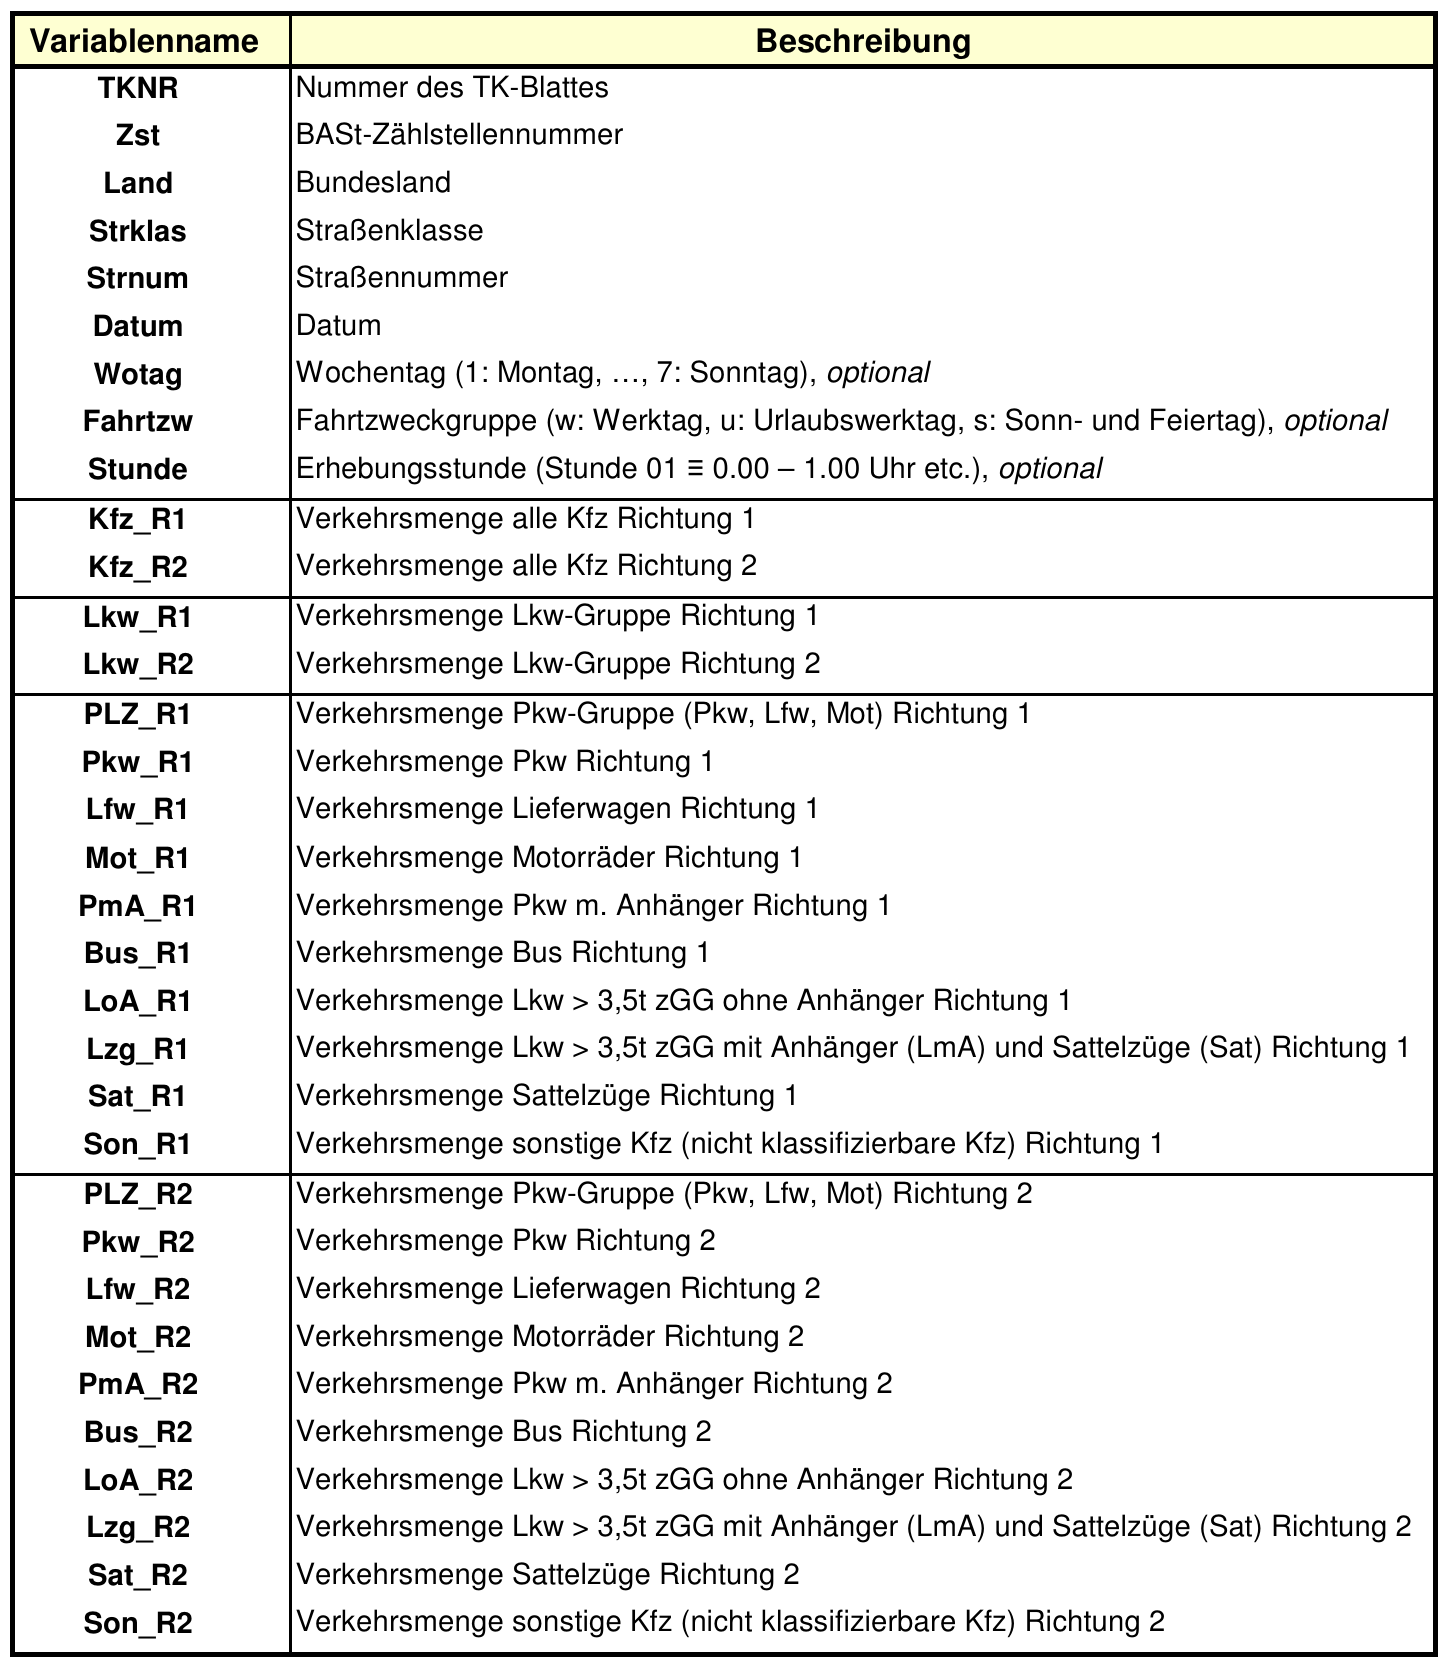

In [7]:
img_colab('variable_names.png', width=600)

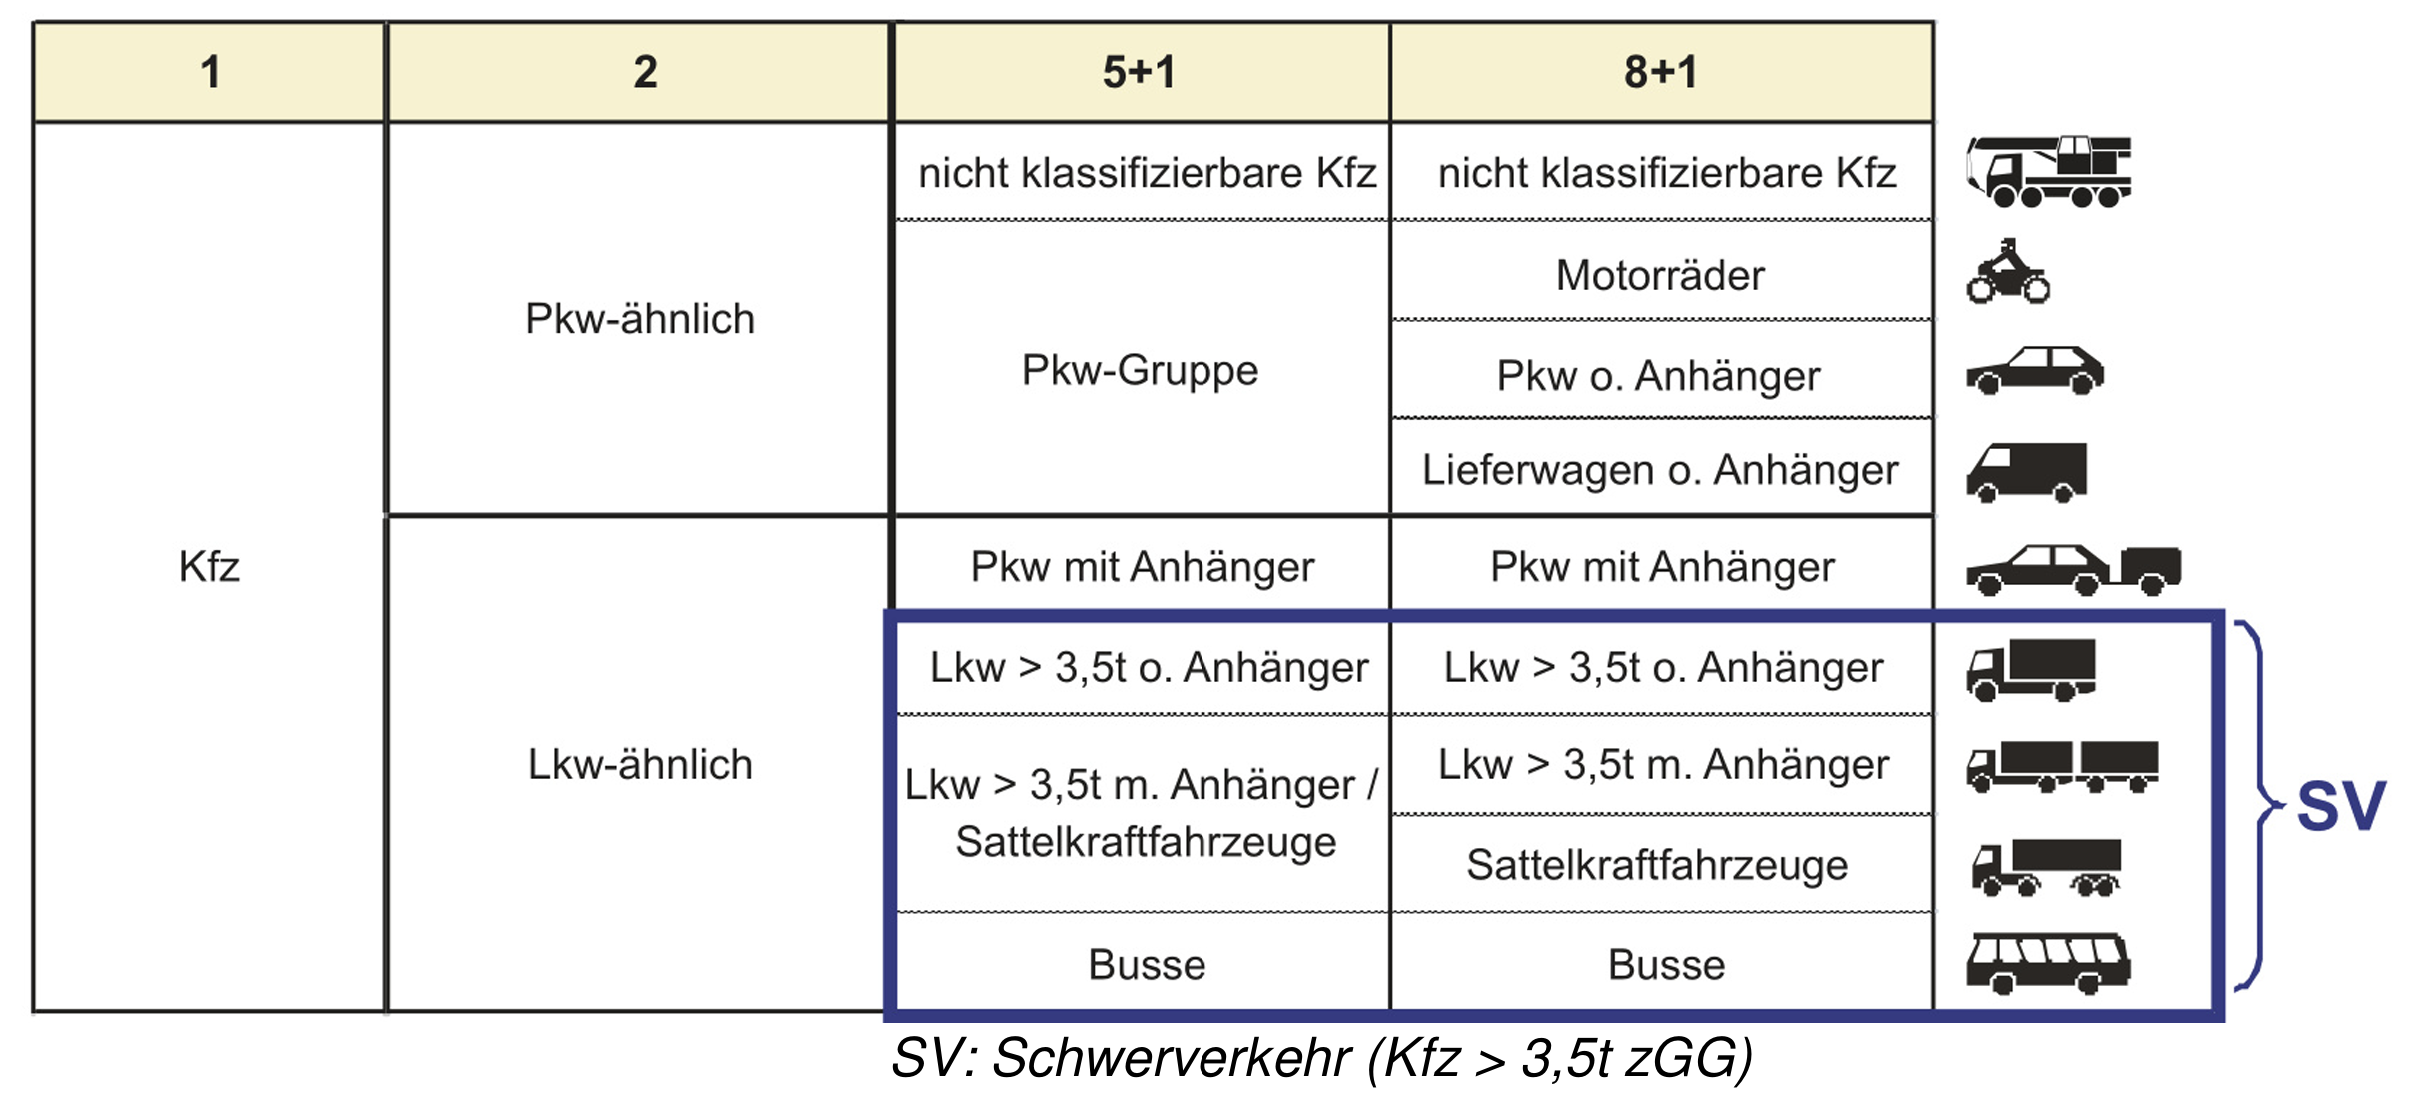

In [8]:
img_colab('vehicle_type.png', width=600)

In [9]:
# rename/translate relevant columns

for x in ['A', 'B']:
    df_complete[x].rename(columns={'Datum': 'date',
                                   'Wotag': 'weekday',
                                   'Stunde': 'hour',
                                   'Landeskuerzel': 'federal_state', 
                                   }, inplace=True)
    for i in ['R1', 'R2']:
        for k in ['','K_']:
            df_complete[x].rename(columns={f'{k}Son_{i}': f'{k}not_classified_{i}',
                                    f'{k}Mot_{i}': f'{k}motorcycles_{i}',
                                    f'{k}Pkw_{i}': f'{k}cars_{i}',
                                    f'{k}Lfw_{i}': f'{k}light_commercial_vehicles_{i}',
                                    f'{k}PmA_{i}': f'{k}passenger_with_trailer_{i}',   
                                    f'{k}LoA_{i}': f'{k}trucks_over3.5t_{i}',
                                    f'{k}Lzg_{i}': f'{k}trucks_over3.5t_with_trailer_{i}',
                                    f'{k}Sat_{i}': f'{k}semi_trailer_truck_{i}',
                                    f'{k}Bus_{i}': f'{k}buses_{i}',
                                    f'{k}Lkw_{i}': f'{k}LKW_like_{i}',
                                    f'{k}PLZ_{i}': f'{k}PKW_like_{i}',
                                    f'{k}KFZ_{i}': f'{k}total_vehicles_{i}',
                                    }, inplace=True)

In [10]:
# Check if panel data is balanced

for x in ['A', 'B']:
    df = df_complete[x]
    counts = df.groupby('Zst')[['date', 'hour']].nunique().prod(axis=1)
    min_obs = counts.min()
    max_obs = counts.max()
    print(f"Panel data for {x}:")
    print(f"  Min observations per Zst: {min_obs}")
    print(f"  Max observations per Zst: {max_obs}")
    if min_obs == max_obs:
        print("  Panel is balanced.")
    else:
        print("  Panel is unbalanced.")

Panel data for A:
  Min observations per Zst: 1440
  Max observations per Zst: 2184
  Panel is unbalanced.
Panel data for B:
  Min observations per Zst: 2184
  Max observations per Zst: 2184
  Panel is balanced.


In [11]:
# Subtract 1 from all hour values 
for x in ['A', 'B']:   
    print(sorted(df_complete[x]['hour'].unique()))
    df_complete[x]['hour'] = df_complete[x]['hour'] - 1
    print(sorted(df_complete[x]['hour'].unique()))

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(24)]
[np.int64(0), np.

In [12]:
# Check date Format
for x in ['A', 'B']:
    print(df_complete[x]['date'].min(), df_complete[x]['date'].max())
    # Convert YYMMDD integer to datetime
    df_complete[x]['date'] = pd.to_datetime(df_complete[x]['date'].astype(str), format='%y%m%d')
    print(df_complete[x]['date'].min(), df_complete[x]['date'].max())

240101 240331
2024-01-01 00:00:00 2024-03-31 00:00:00
240101 240331
2024-01-01 00:00:00 2024-03-31 00:00:00


In [13]:
# Create a combined date_hour variable

for x in ['A', 'B']:
    # Ensure 'date' is datetime and 'hour' is integer
    df_complete[x]['date_hour'] = pd.to_datetime(df_complete[x]['date']) + pd.to_timedelta(df_complete[x]['hour'], unit='h')

print(df_complete['A'][['date_hour', 'hour', 'date']])

                  date_hour  hour       date
0       2024-01-01 00:00:00     0 2024-01-01
1       2024-01-01 01:00:00     1 2024-01-01
2       2024-01-01 02:00:00     2 2024-01-01
3       2024-01-01 03:00:00     3 2024-01-01
4       2024-01-01 04:00:00     4 2024-01-01
...                     ...   ...        ...
2667763 2024-03-31 19:00:00    19 2024-03-31
2667764 2024-03-31 20:00:00    20 2024-03-31
2667765 2024-03-31 21:00:00    21 2024-03-31
2667766 2024-03-31 22:00:00    22 2024-03-31
2667767 2024-03-31 23:00:00    23 2024-03-31

[2667768 rows x 3 columns]


Since the datasets are raw and not yet cleaned, I will check for missing values and outliers. Missing values can occur due to various reasons, such as sensor malfunctions or data transmission errors. Outliers may arise from unusual traffic conditions or data entry errors. Identifying and addressing these issues is crucial for ensuring the accuracy and reliability of subsequent analyses.

By default the dataset contains for each traffic count per vehicle type a separate column that flags the quality of the measurement that faciliates the identification of missing values. Outliers are common in traffic data, and may be explainable by special events such as holidays, road works, accidents, or major public events. However, in this preliminary analysis, I will focus on identifying extreme outliers that are likely due to data errors. 


In [14]:
# List number of occurrences for each value in columns starting with "K_"

print(df_complete['A']['K_total_vehicles_R1'].value_counts(dropna=False))
print("-" * 40)

for val in df_complete['B']['K_total_vehicles_R1'].unique():
    print(f"Summary statistics for total_vehicles__R1 where K_total_vehicles_R1 = {val}:")
    print(df_complete['B'][df_complete['B']['K_total_vehicles_R1'] == val]['total_vehicles_R1'].describe())
    print("-" * 40)

K_total_vehicles_R1
-    1793797
s     446406
a     350411
k      75269
z       1229
u        656
Name: count, dtype: int64
----------------------------------------
Summary statistics for total_vehicles__R1 where K_total_vehicles_R1 = s:
count    240964.000000
mean        301.630289
std         423.599532
min           0.000000
25%          48.000000
50%         165.000000
75%         373.000000
max        5943.000000
Name: total_vehicles_R1, dtype: float64
----------------------------------------
Summary statistics for total_vehicles__R1 where K_total_vehicles_R1 = -:
count    1.352601e+06
mean     2.610501e+02
std      3.785959e+02
min      0.000000e+00
25%      3.900000e+01
50%      1.420000e+02
75%      3.290000e+02
max      6.082000e+03
Name: total_vehicles_R1, dtype: float64
----------------------------------------
Summary statistics for total_vehicles__R1 where K_total_vehicles_R1 = k:
count    14088.000000
mean       230.022785
std        302.279314
min          0.000000
25%   

In [15]:
# Change incorrect values (K_ variables containing 'a') to NaN

for x in ['A', 'B']:
    df = df_complete[x]
    r_cols = [col for col in df.columns if re.search(r'(_R1$|_R2$)', col) and not col.startswith('K_')]
    for r_col in r_cols:
        k_col = 'K_' + r_col
        if k_col in df.columns:
            mask = df[k_col] == 'a'
            df.loc[mask, r_col] = np.nan

In [16]:
# Replace values of variables ending with R1 or R2 with the previous period value if the corresponding K_ variable is "a"

for x in ['A', 'B']:
    df = df_complete[x]
    r_cols = [col for col in df.columns if re.search(r'(_R1$|_R2$)', col) and not col.startswith('K_')]
    for r_col in r_cols:
        k_col = 'K_' + r_col
        if k_col in df.columns:
            # Sort by Zst and date_hour for panel structure
            df.sort_values(['Zst', 'date_hour'], inplace=True)
            # Set to NaN where K_ column is 'a'
            mask = df[k_col] == 'a'
            df.loc[mask, r_col] = np.nan
            # Forward fill within each Zst group
            df[r_col] = df.groupby('Zst')[r_col].ffill()

In order to create a *traffic intensity per capita* metric population data per state has to be added to the traffic dataset.

In [17]:
for x in ['A', 'B']:
    df_complete[x] = df_complete[x].merge(pop, on='federal_state', how='left')

## Data Exploration

First, I will analyze the location of traffic counting stations across Germany for both road types. This will help to understand the spatial distribution of the data and identify any potential gaps in coverage.

In [18]:
# Count the number of traffic stations for each dataset A and B
print("-" * 40)
for x in ['A', 'B']:
    print(f"Road Type:{x}")
    num_unique_zst = df_complete[x]['Zst'].nunique()
    min_date = df_complete[x]['date'].min()
    max_date = df_complete[x]['date'].max()
    print(f"Dates covered:: from {min_date} to {max_date}")
    print(f"Number of unique dates: {df_complete[x]['date'].nunique()}")
    print(f"Number of unique combinations of date and hour: {df_complete[x].groupby(['date', 'hour']).ngroups}")
    min_total_vehicles = df_complete[x][['total_vehicles_R1', 'total_vehicles_R2']].min()
    max_total_vehicles = df_complete[x][['total_vehicles_R1', 'total_vehicles_R2']].max()
    print(f"Range of vehicle (all vehicle types) traffic count: [{min_total_vehicles.values[0]}, {max_total_vehicles.values[0]}]")
    print("-" * 40)


----------------------------------------
Road Type:A
Dates covered:: from 2024-01-01 00:00:00 to 2024-03-31 00:00:00
Number of unique dates: 91
Number of unique combinations of date and hour: 2184
Range of vehicle (all vehicle types) traffic count: [0.0, 8327.0]
----------------------------------------
Road Type:B
Dates covered:: from 2024-01-01 00:00:00 to 2024-03-31 00:00:00
Number of unique dates: 91
Number of unique combinations of date and hour: 2184
Range of vehicle (all vehicle types) traffic count: [0.0, 6082.0]
----------------------------------------


In [19]:
# Create GeoDataFrames for traffic stations
gdf = {}
for x in ['A', 'B']:
    gdf[x] = gpd.GeoDataFrame(
        df_complete[x].drop_duplicates("Zst")[["Zst", "Koordinaten_UTM32_E", "Koordinaten_UTM32_N"]],
        geometry=gpd.points_from_xy(
            df_complete[x].drop_duplicates("Zst")["Koordinaten_UTM32_E"],
            df_complete[x].drop_duplicates("Zst")["Koordinaten_UTM32_N"]
        ),
        crs="EPSG:32632"
    ).to_crs(epsg=3857) 

network_A = network_data[network_data["Str_Klasse_kurz"] == "A"]
network_A = network_A.to_crs(epsg=3857)
network_B = network_data[network_data["Str_Klasse_kurz"] == "B"]
network_B = network_B.to_crs(epsg=3857)

gdf_A = gdf["A"].to_crs(epsg=3857)
gdf_B = gdf["B"].to_crs(epsg=3857)

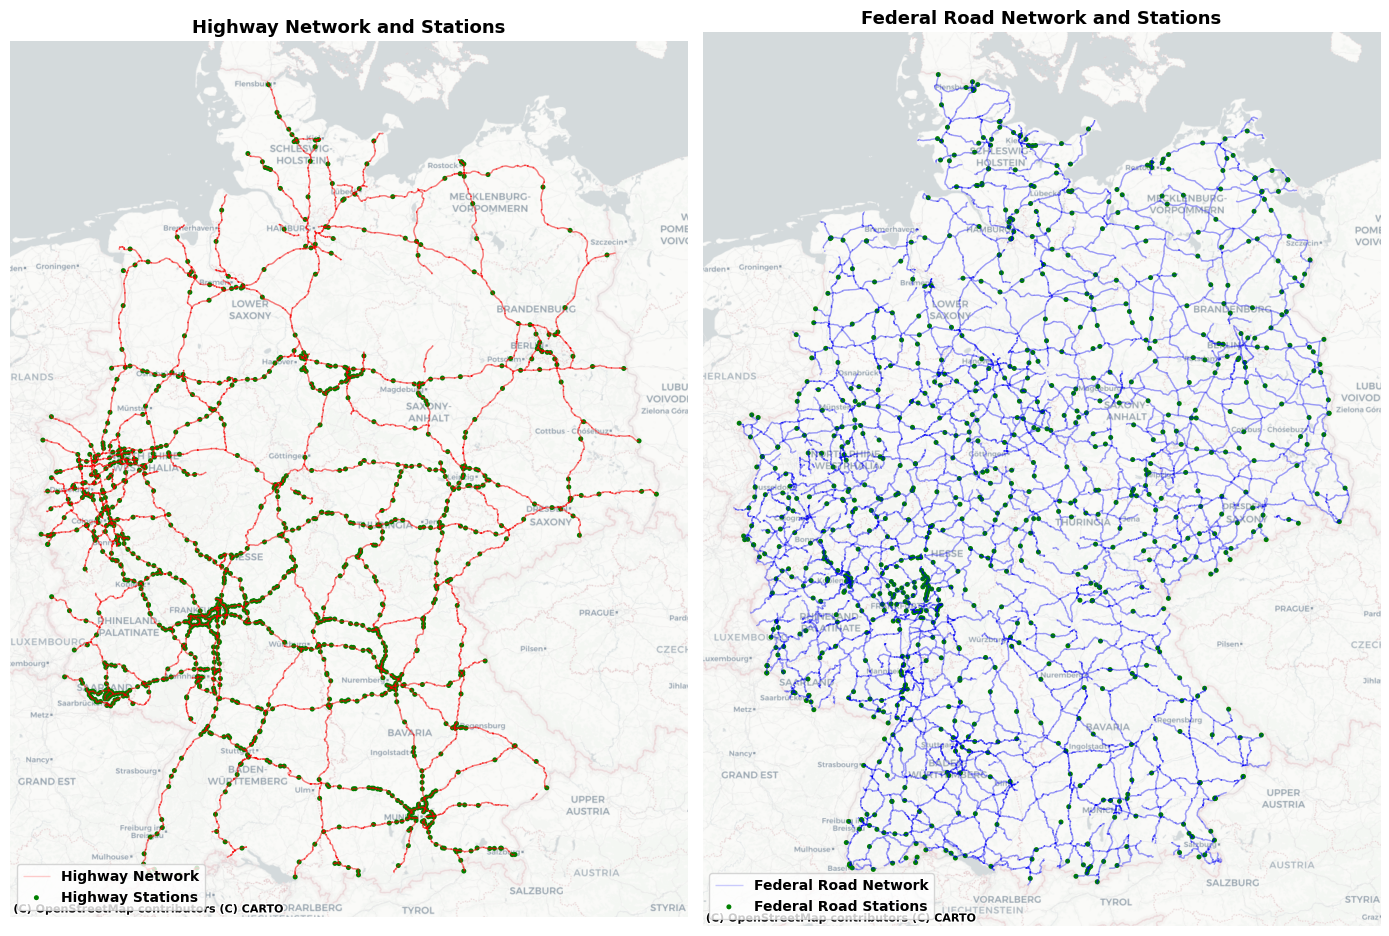

In [20]:
# Plot Stations and Road Networks
fig, axes = plt.subplots(1, 2, figsize=(14, 10))

ax1 = axes[0]
network_A.plot(ax=ax1, color="red", linewidth=1, alpha=0.2, label="Highway Network")
gdf_A.plot(ax=ax1, color="green", markersize=13, edgecolor="none", label="Highway Stations")
ctx.add_basemap(ax1, source=ctx.providers.CartoDB.Positron, zoom=7)
ax1.set_title("Highway Network and Stations", fontsize=13, fontweight="bold")
ax1.legend(frameon=True, loc="lower left")
ax1.set_axis_off()

ax2 = axes[1]
network_B.plot(ax=ax2, color="blue", linewidth=1, alpha=0.2, label="Federal Road Network")
gdf_B.plot(ax=ax2, color="green", markersize=13, edgecolor="none", label="Federal Road Stations")
ctx.add_basemap(ax2, source=ctx.providers.CartoDB.Positron, zoom=7)
ax2.set_title("Federal Road Network and Stations", fontsize=13, fontweight="bold")
ax2.legend(frameon=True, loc="lower left")
ax2.set_axis_off()

plt.tight_layout()
plt.savefig("Fig1.pdf", format="pdf")  
plt.show()



Indeed the distribution of traffic counting stations is not uniform across Germany. As expected, highways (road type A) have a denser network of counting stations compared to federal roads (road type B), whereas the federal road network is much more denser. This is likely due to the higher traffic volumes and strategic importance of highways in the national road network. Moreover, traffic counting stations are more concentrated around major urban areas and along key transportation corridors.

In [21]:
for x in ['A', 'B']:
    print(f"Road Type: {x}")
    print(f"Number of unique Zst: {df_complete[x]['Zst'].nunique()}")

Road Type: A
Number of unique Zst: 1229
Road Type: B
Number of unique Zst: 885


In [22]:
# Information traffic stations (example highway)
df_complete['A'].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2667768 entries, 0 to 2667767
Data columns (total 73 columns):
 #   Column                             Dtype         
---  ------                             -----         
 0   TKNR                               int64         
 1   Zst                                int64         
 2   Land                               int64         
 3   Strklas                            object        
 4   Strnum                             object        
 5   date                               datetime64[ns]
 6   weekday                            int64         
 7   Fahrtzw                            object        
 8   hour                               int64         
 9   total_vehicles_R1                  float64       
 10  K_total_vehicles_R1                object        
 11  total_vehicles_R2                  float64       
 12  K_total_vehicles_R2                object        
 13  LKW_like_R1                        float64       
 14  K_

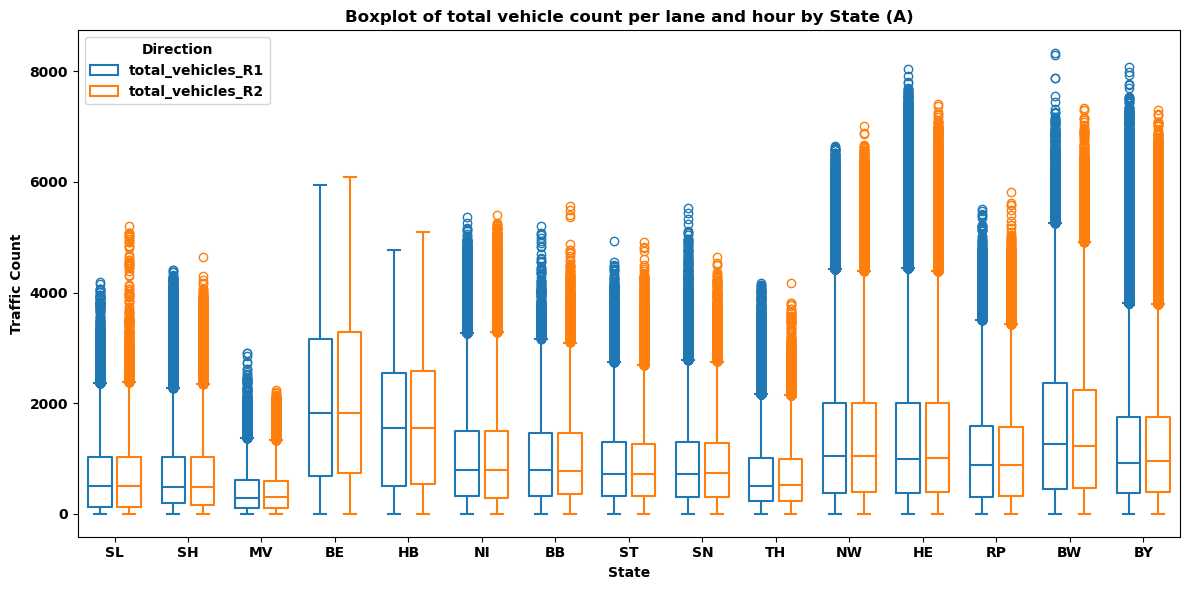

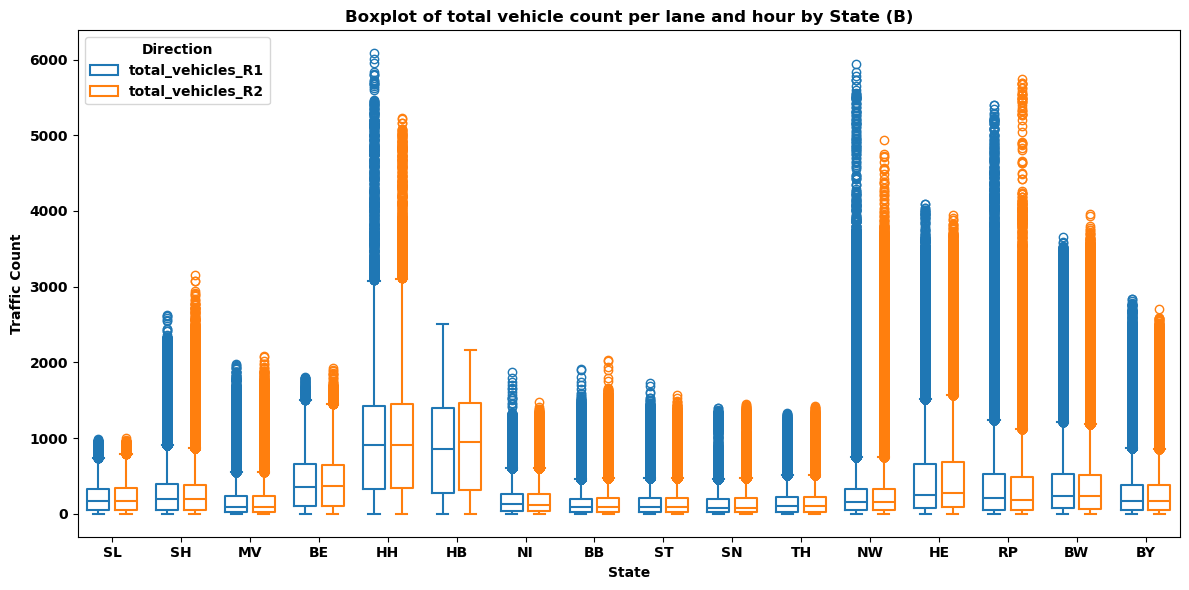

In [23]:
# Plot boxplots for KFZ_R1 and KFZ_R2 by federal state and road type
for x in ['A', 'B']:
    df = df_complete[x]
    # Melt the dataframe for boxplot
    df_melted = df.melt(id_vars=['federal_state'], value_vars=['total_vehicles_R1', 'total_vehicles_R2'],
                        var_name='Direction', value_name='TrafficCount')
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_melted, x='federal_state', y='TrafficCount', hue='Direction', fill=False, gap=0.2)
    plt.title(f'Boxplot of total vehicle count per lane and hour by State ({x})')
    plt.xlabel('State')
    plt.ylabel('Traffic Count')
    plt.legend(title='Direction')
    plt.tight_layout()
    plt.show()

As expected, we observe similar traffic volumnes for the the different directions . While a substatial variation in hourly traffic volumes across states can be observed from the boxplots above, extreme outliers are not present in the data. Clearly, the distributions per federal state are positive skeweed with a longer tail for federal roads compared to highways. However, no structual outliers exist that might skew the distribution as a whole. Thus, no further cleansing is required at this stage.

Notice, that the citystate Hamburg (HH) doesn't have measures for highway traffic counts. This is simply because there are not highway traffic counting station located within the city limits of Hamburg. This explains the relatively high traffic counts on federal roads in Hamburg compared to other states.

Further, the plot displays a common challange dealing with traffic data which is that traffic counts are highly correlated with population size. Hence, for comparison purposes, a better measure would be normalized indicators such as *traffic intensity per capita*.

Second, for better understanding we reclassify the vehicle types into two main categories: passenger vehicles and freight vehicles. Passenger vehicles include cars, motorcycles, light commercial vehicles, and buses, while freight vehicles encompass trucks and heavy goods vehicles. This reclassification allows us to analyze traffic patterns based on the primary purpose of travel, distinguishing between personal mobility and goods transportation.

In [24]:
# group by freight and person transport (aggregation of relevant columns)
for x in ['A', 'B']:
    for i in ['R1', 'R2']:
        df_complete[x][f'person_transport_{i}'] = df_complete[x][
            [f'motorcycles_{i}', f'cars_{i}', f'passenger_with_trailer_{i}', f'buses_{i}']
        ].sum(axis=1)

        df_complete[x][f'freight_transport_{i}'] = df_complete[x][
            [f'light_commercial_vehicles_{i}', f'trucks_over3.5t_{i}', f'trucks_over3.5t_with_trailer_{i}', f'semi_trailer_truck_{i}']
        ].sum(axis=1)

Since the traffic volume data are aggregated per lane, further aggregation across lanes is required to obtain total traffic counts per vehicle type at each specific location. To examine the temporal dimension of the dataset, the evolution of traffic volumes by vehicle type is visualized over time for both road categories. This time-series analysis facilitates the identification of underlying trends, seasonal patterns, and potential anomalies in traffic flow dynamics.

In [25]:
# Create aggregate (both directions) traffic counts per Zst, hour, and date 
# Sum all columns that start with 'R' and end with the same suffix (e.g., R1 and R2)

for x in ['A', 'B']:
    # Find all columns ending with _R1
    r1_cols = [col for col in df_complete[x].columns if re.search(r'_R1$', col) and not col.startswith('K_')]
    for r1 in r1_cols:
        prefix = r1[:-3]  # Remove '_R1' to get the prefix
        r2 = prefix + '_R2'
        if r2 in df_complete[x].columns:
            sum_col = prefix + '_R1_R2'
            df_complete[x][sum_col] = df_complete[x][r1] + df_complete[x][r2]

print([col for col in df_complete['A'].columns if col.endswith('R1_R2')])

['total_vehicles_R1_R2', 'LKW_like_R1_R2', 'PKW_like_R1_R2', 'cars_R1_R2', 'light_commercial_vehicles_R1_R2', 'motorcycles_R1_R2', 'passenger_with_trailer_R1_R2', 'buses_R1_R2', 'trucks_over3.5t_R1_R2', 'trucks_over3.5t_with_trailer_R1_R2', 'semi_trailer_truck_R1_R2', 'not_classified_R1_R2', 'person_transport_R1_R2', 'freight_transport_R1_R2']


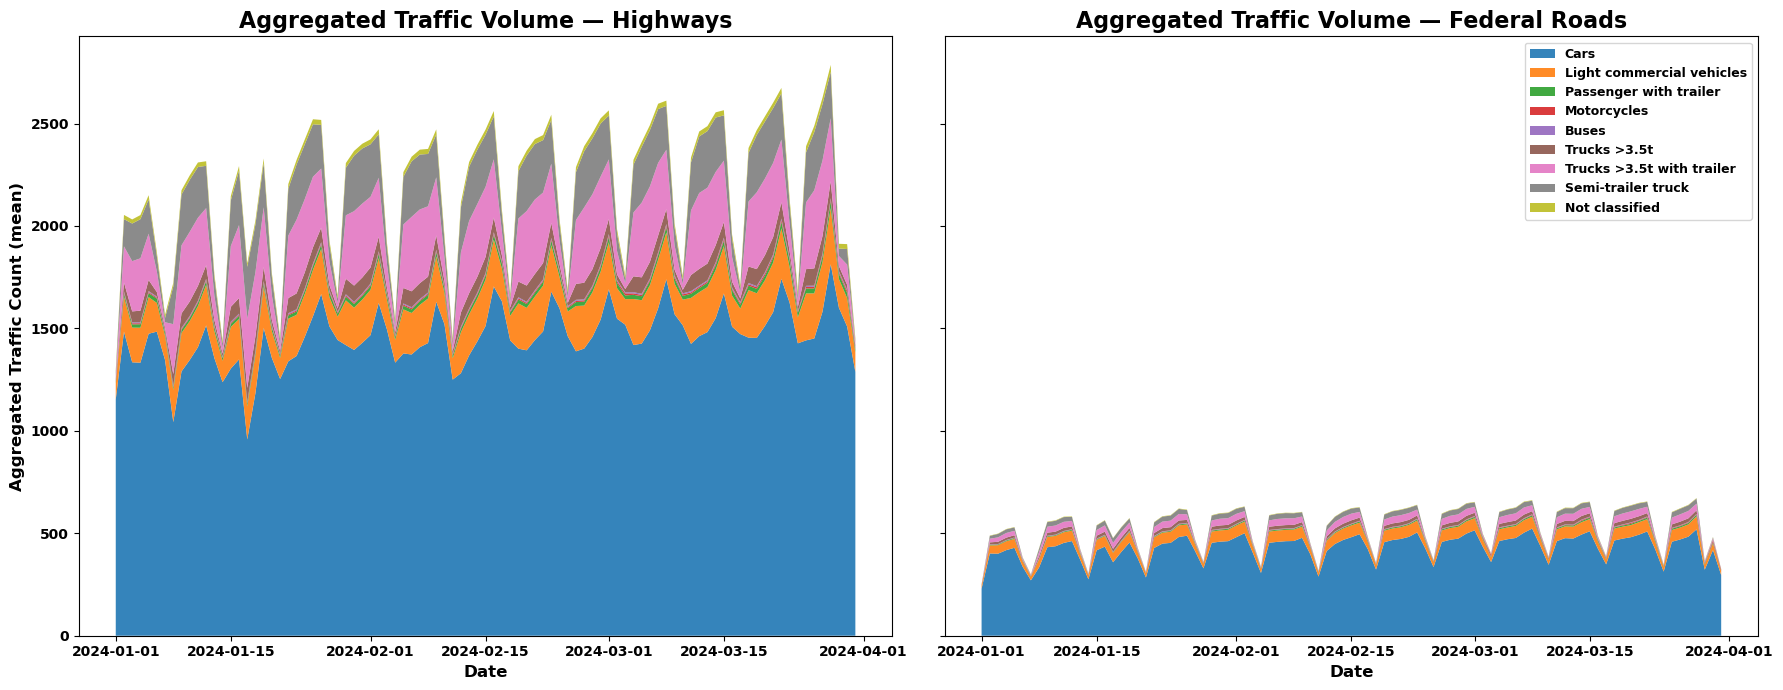

In [26]:
vehicle_cols = [
    'cars_R1_R2', 'light_commercial_vehicles_R1_R2', 'passenger_with_trailer_R1_R2', 'motorcycles_R1_R2', 'buses_R1_R2',
    'trucks_over3.5t_R1_R2', 'trucks_over3.5t_with_trailer_R1_R2', 'semi_trailer_truck_R1_R2', 'not_classified_R1_R2'
]

# aggregate means
agg_A = (
    df_complete['A']
    .groupby('date')[vehicle_cols]
    .mean()
    .sort_index()
    .reset_index()
)

agg_B = (
    df_complete['B']
    .groupby('date')[vehicle_cols]
    .mean()
    .sort_index()
    .reset_index()
)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

# highways
axes[0].stackplot(
    agg_A['date'],
    [agg_A[c] for c in vehicle_cols],
    labels=['Cars', 'Light commercial vehicles', 'Passenger with trailer', 'Motorcycles', 'Buses',
            'Trucks >3.5t', 'Trucks >3.5t with trailer', 'Semi-trailer truck', 'Not classified'],
    linewidth=0,
    alpha=0.9
)
axes[0].set_title("Aggregated Traffic Volume — Highways", fontsize=16, weight='bold')
axes[0].set_xlabel("Date", fontsize=12)
axes[0].set_ylabel("Aggregated Traffic Count (mean)", fontsize=12)
axes[0].grid(False)

# federal roads
axes[1].stackplot(
    agg_B['date'],
    [agg_B[c] for c in vehicle_cols],
    labels=['Cars', 'Light commercial vehicles', 'Passenger with trailer', 'Motorcycles', 'Buses',
            'Trucks >3.5t', 'Trucks >3.5t with trailer', 'Semi-trailer truck', 'Not classified'],
    linewidth=0,
    alpha=0.9
)
axes[1].set_title("Aggregated Traffic Volume — Federal Roads", fontsize=16, weight='bold')
axes[1].set_xlabel("Date", fontsize=12)
axes[1].grid(False)
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.savefig("Fig2.pdf", format="pdf")  
plt.show()


The figure above illustrates the temporal evolution of traffic volumes for both highways and federal roads, segmented by vehicle types. Striking is the significant difference of traffic volumes between highways and federal roads, with highways consistently exhibiting higher traffic counts across all vehicle categories. Passenger vehicles dominate the traffic composition on both road types, reflecting their primary role in personal mobility. Freight vehicles, while constituting a smaller proportion of total traffic, display notable peaks that may correspond to specific logistics activities or delivery schedules.

Indeed, we observe interesting daily traffic patterns, which will be further analyzed in the following section with a focus on intra-week and intra-day traffic intensity cycles. Moreover, a notable decline in overall traffic volume is evident on January 17, 2024 (Wednesday), disrupting these regular patterns. This anomaly coincides with a period of severe black ice across Germany, caused by freezing rain that led to widespread road closures and numerous accidents. The German Weather Service (DWD) issued high-level weather warnings, prompting many individuals to stay and work from home to minimize travel risks. Additionally, schools in several regions were closed or transitioned to remote learning, further contributing to the temporary reduction in traffic volumes.

In [27]:
# Optain German Geodataframe
ne_path = shp.natural_earth(resolution='10m',
                            category='cultural',
                            name='admin_1_states_provinces')
gdf_all = gpd.read_file(ne_path)
states = gdf_all[gdf_all["admin"].eq("Germany")].copy()

# Population Data and Average Traffic Counts (Federal Roads) by Federal State
df = (
    df_complete['B']
      .assign(
          log_total_vehicles=lambda x: np.where(
              x["total_vehicles_R1_R2"] > 0,
              np.log(x["total_vehicles_R1_R2"]),
              np.nan  
          )
      )
      .groupby("federal_state", as_index=False)
      .agg({
          "population": "first",
          "total_vehicles_R1_R2": "mean",
          "log_total_vehicles": "mean"
      })
      .rename(columns={
          "total_vehicles_R1_R2": "avg_traffic_count_B",
          "log_total_vehicles": "avg_log_traffic_count_B"
      })
)
df["iso_code_prefixed"] = "DE-" + df["federal_state"]

# Population Data and Average Traffic Counts (Highways) by Federal State

df_A = (
    df_complete['A']
      .assign(
          log_total_vehicles=lambda x: np.where(
              x["total_vehicles_R1_R2"] > 0,
              np.log(x["total_vehicles_R1_R2"]),
              np.nan  
          )
      )
      .groupby("federal_state", as_index=False)
      .agg({
          "total_vehicles_R1_R2": "mean",
          "log_total_vehicles": "mean"
      })
      .rename(columns={
          "total_vehicles_R1_R2": "avg_traffic_count_A",
          "log_total_vehicles": "avg_log_traffic_count_A"
      })
)
df_A["iso_code_prefixed"] = "DE-" + df_A["federal_state"]

# Merging the dataframes
df = df.merge(df_A, how="left", on="iso_code_prefixed")

# Traffic Intensity per Capita (Volume)
df["traffic_intensity_pc_B"] = np.log(df["avg_traffic_count_B"] / df["population"])
df["traffic_intensity_pc_A"] = np.log(df["avg_traffic_count_A"] / df["population"])

# Merging ISO Code for Plotting German Map
merged = states.merge(df, how="left", left_on="iso_3166_2", right_on="iso_code_prefixed")

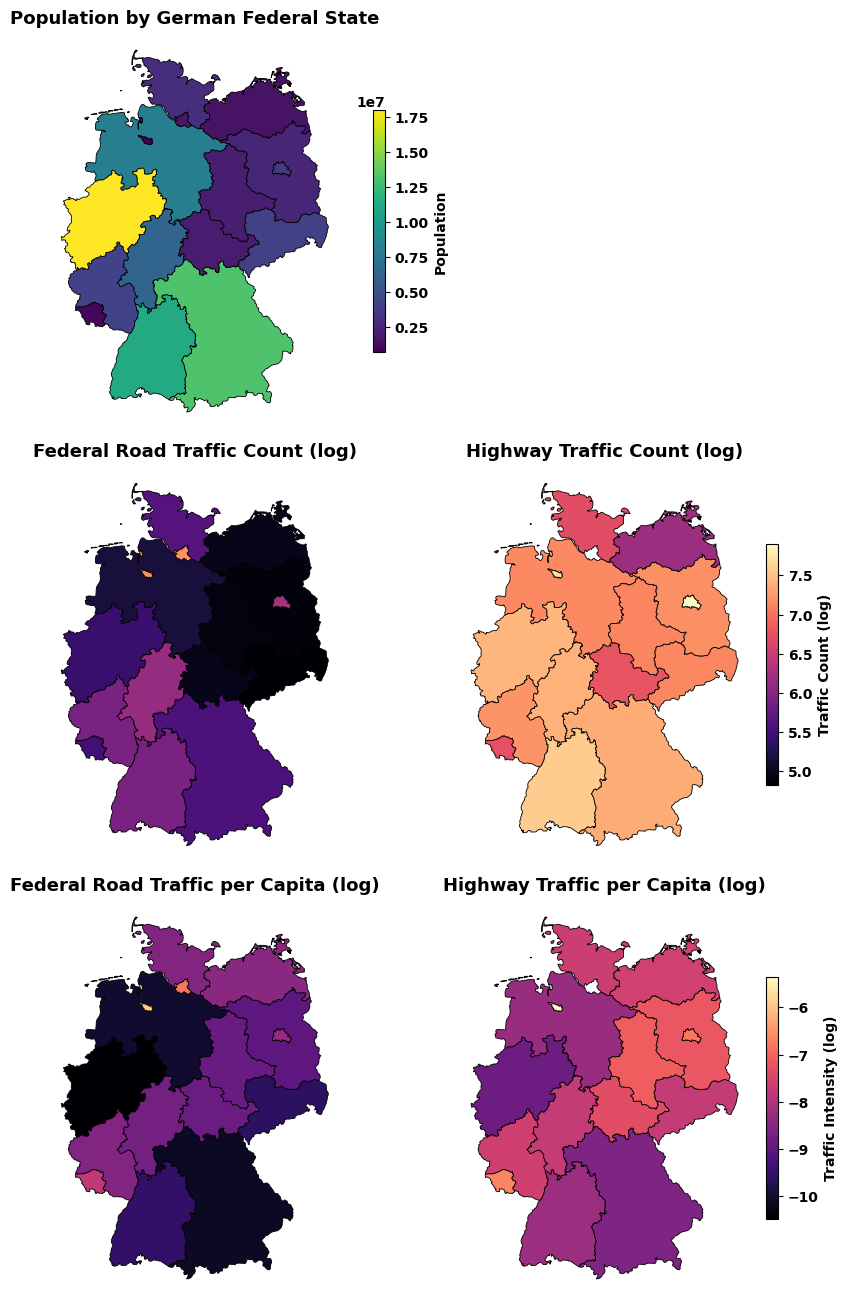

In [28]:

fig = plt.figure(figsize=(8, 13), constrained_layout=True)
gs = gridspec.GridSpec(3, 2, figure=fig)


ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

# Population Plot
merged.plot(
    column="population",
    ax=ax1,
    legend=True,
    cmap="viridis",
    edgecolor="black",
    linewidth=0.6,
    legend_kwds={"label": "Population", "shrink": 0.6}
)
ax1.set_title("Population by German Federal State", fontsize=13)
ax1.set_axis_off()

# Traffic Volume (log) Plot
vmin_2_3 = merged[["avg_log_traffic_count_A", "avg_log_traffic_count_B"]].min().min()
vmax_2_3 = merged[["avg_log_traffic_count_A", "avg_log_traffic_count_B"]].max().max()
shared_legend_kwds_2_3 = {"label": "Traffic Count (log)", "shrink": 0.6}

merged.plot(
    column="avg_log_traffic_count_B",
    ax=ax2,
    cmap="magma",
    legend=False,
    edgecolor="black",
    linewidth=0.6,
    vmin=vmin_2_3, vmax=vmax_2_3,
    legend_kwds=shared_legend_kwds_2_3
)
ax2.set_title("Federal Road Traffic Count (log)", fontsize=13)
ax2.set_axis_off()

merged.plot(
    column="avg_log_traffic_count_A",
    ax=ax3,
    cmap="magma",
    legend=True,
    edgecolor="black",
    linewidth=0.6,
    vmin=vmin_2_3, vmax=vmax_2_3,
    legend_kwds=shared_legend_kwds_2_3
)
ax3.set_title("Highway Traffic Count (log)", fontsize=13)
ax3.set_axis_off()

# Traffic Intensity (log) Plot
vmin_4_5 = merged[["traffic_intensity_pc_B", "traffic_intensity_pc_A"]].min().min()
vmax_4_5 = merged[["traffic_intensity_pc_B", "traffic_intensity_pc_A"]].max().max()
shared_legend_kwds_4_5 = {"label": "Traffic Intensity (log)", "shrink": 0.6}

merged.plot(
    column="traffic_intensity_pc_B",
    ax=ax4,
    cmap="magma",
    legend=False,
    edgecolor="black",
    linewidth=0.6,
    vmin=vmin_4_5, vmax=vmax_4_5,
    legend_kwds=shared_legend_kwds_4_5
)
ax4.set_title("Federal Road Traffic per Capita (log)", fontsize=13)
ax4.set_axis_off()

merged.plot(
    column="traffic_intensity_pc_A",
    ax=ax5,
    cmap="magma",
    legend=True,
    edgecolor="black",
    linewidth=0.6,
    vmin=vmin_4_5, vmax=vmax_4_5,
    legend_kwds=shared_legend_kwds_4_5
)
ax5.set_title("Highway Traffic per Capita (log)", fontsize=13)
ax5.set_axis_off()

plt.show()


The figure presents a comparative view of traffic activity across German federal states, distinguishing between total traffic counts and traffic intensity per capita on both federal roads and highways. While the middle row shows the overall magnitude of vehicle flows, the bottom row adjusts these values by population, capturing how much traffic each resident is effectively associated with. Using logarithmic scales highlights relative rather than absolute differences, making spatial contrasts clearer. Examining traffic intensity per capita is particularly important because it normalizes for population size, revealing states where road networks bear a disproportionately high load relative to the number of people. This perspective provides a more equitable measure of infrastructure use and transport dependence, helping identify regions that may experience higher per-resident traffic pressure or require targeted transport planning interventions. It should be noted that the observation period (January–March 2024) coincides with winter holidays in some states but does not include major holiday periods such as the summer break, which could otherwise distort the comparison due to typically higher traffic volumes observed in southern states during that season.

Next, we are going to take a closer look at different categories of vehicle types by considering across lane aggregated traffic volumnes. Similarly as shown before, highways have a significantly higher traffic volumnes compared to federal roads. Further, passenger vehicles dominate the overall traffic volumes on both road types. However, freight vehicles account for a substantial share of total traffic, particularly on highways where logistics and long-distance freight transport are more prevalent. 

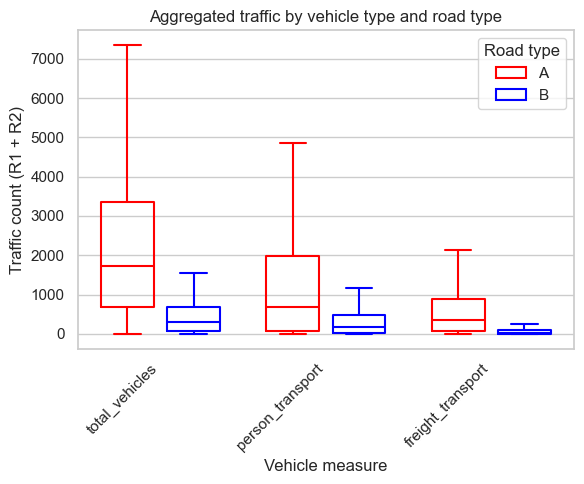

In [ ]:
# Create boxplots per vehicle measure with Road Type A and B next to each other.
sns.set(style="whitegrid")
agg_measures = ['total_vehicles', 'person_transport', 'freight_transport',]

rows = []
for road in ['A', 'B']:
    df = df_complete[road]
    # collect present aggregated columns
    plot_cols = [f'{m}_R1_R2' for m in agg_measures]
    tmp = df[plot_cols].copy()
    tmp['road_type'] = road
    tmp = tmp.melt(id_vars='road_type', var_name='measure', value_name='traffic')
    rows.append(tmp)

combined = pd.concat(rows, ignore_index=True)

combined['measure_short'] = combined['measure'].str.replace('_R1_R2$', '', regex=True)

plt.figure(figsize=(6, 5))
sns.boxplot(data=combined, x='measure_short', y='traffic', hue='road_type',
            palette={'A': 'red', 'B': 'blue'}, showfliers=False,  fill=False, gap=0.2)
plt.xlabel('Vehicle measure')
plt.ylabel('Traffic count (R1 + R2)')
plt.title('Aggregated traffic by vehicle type and road type')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Road type', loc='upper right')
plt.tight_layout()
plt.show()


After examining overall spatial traffic patterns, we now turn to temporal patterns, which are particularly relevant for the subsequent analysis of the GDL strike impact. Traffic volumes are expected to exhibit strong temporal regularities, with distinct variations by hour of the day and day of the week. Peak traffic typically occurs during weekday mornings and evenings, reflecting commuting activity, while weekends generally experience lower volumes. Freight transport patterns, in contrast, are largely driven by logistics schedules and legal driving restrictions that apply from Friday afternoon through Sunday. To better understand these dynamics, we visualize intra-day and intra-week traffic patterns for both passenger and freight transport.

In [30]:
agg_measures = ['total_vehicles', 'person_transport', 'freight_transport']

df_cycle = {}

for road in ['A', 'B']:
    df = df_complete[road]
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    for m in agg_measures:
        # Traffic intensity week/day cycles:
        df[f"intensity_{m}_{road}"] = df[f"{m}_R1_R2"] / df["population"]
        #Intra-Week
        df['week'] = df['date'].dt.isocalendar().week
        df[f'week_mean_int_{m}_{road}'] = (
            df
            .groupby(['Zst', 'week'])[f'intensity_{m}_{road}']
            .transform('mean')
        )
        df[f'intra_week_int_{m}_{road}'] = (
            df[f'intensity_{m}_{road}'] - df[f'week_mean_int_{m}_{road}']
        )
        # Intra-Day
        df[f'day_mean_int_{m}_{road}'] = (
            df
            .groupby(['Zst', 'date'])[f'intensity_{m}_{road}']
            .transform('mean')
        )
        df[f'intra_day_int_{m}_{road}'] = (
            df[f'intensity_{m}_{road}'] - df[f'day_mean_int_{m}_{road}']
        )
    df_cycle[road] = df


In [31]:
# Keeping relevant columns for analysis

keep_prefixes = ("intensity_", "week_mean_int_", "day_mean_int_", "intra_week_int_", "intra_day_int_")
keep_columns = ["Zst", "date_hour", "hour", "date", "federal_state"]

def select_cols(df):
    """Select only relevant columns (ID + target prefixes)."""
    cols = keep_columns + [c for c in df.columns if c.startswith(keep_prefixes)]
    return df.loc[:, pd.unique(cols)]

dfA = select_cols(df_cycle["A"]).copy()
dfA["road"] = "A"
dfB = select_cols(df_cycle["B"]).copy()
dfB["road"] = "B"

# Concatenate vertically (stack)
df_concat = pd.concat([dfA, dfB], ignore_index=True)


In [32]:
# Average Cycles of Traffic Intensity
df_concat["weekday"] = df_concat["date_hour"].dt.day_name()
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

intraweek_int = {}
intraday_int = {}

for x in ['A', 'B']:
    for m in agg_measures:
        # Traffic Intensity
        # Intra-week
        col = f"intra_week_int_{m}_{x}"
        intraweek_int[(m, x)] = (
            df_concat
            .groupby("weekday")[col]
            .agg(
                q25=lambda s: s.quantile(0.25),
                q75=lambda s: s.quantile(0.75),
                mean="mean"
            )
            .reindex(weekday_order)
        )
        # Intra-day
        col = f"intra_day_int_{m}_{x}"
        intraday_int[(m, x)] = (
            df_concat
            .groupby("hour")[col]
            .agg(
                q25=lambda s: s.quantile(0.25),
                q75=lambda s: s.quantile(0.75),
                mean="mean"
            )
            .reindex(range(24))
        )

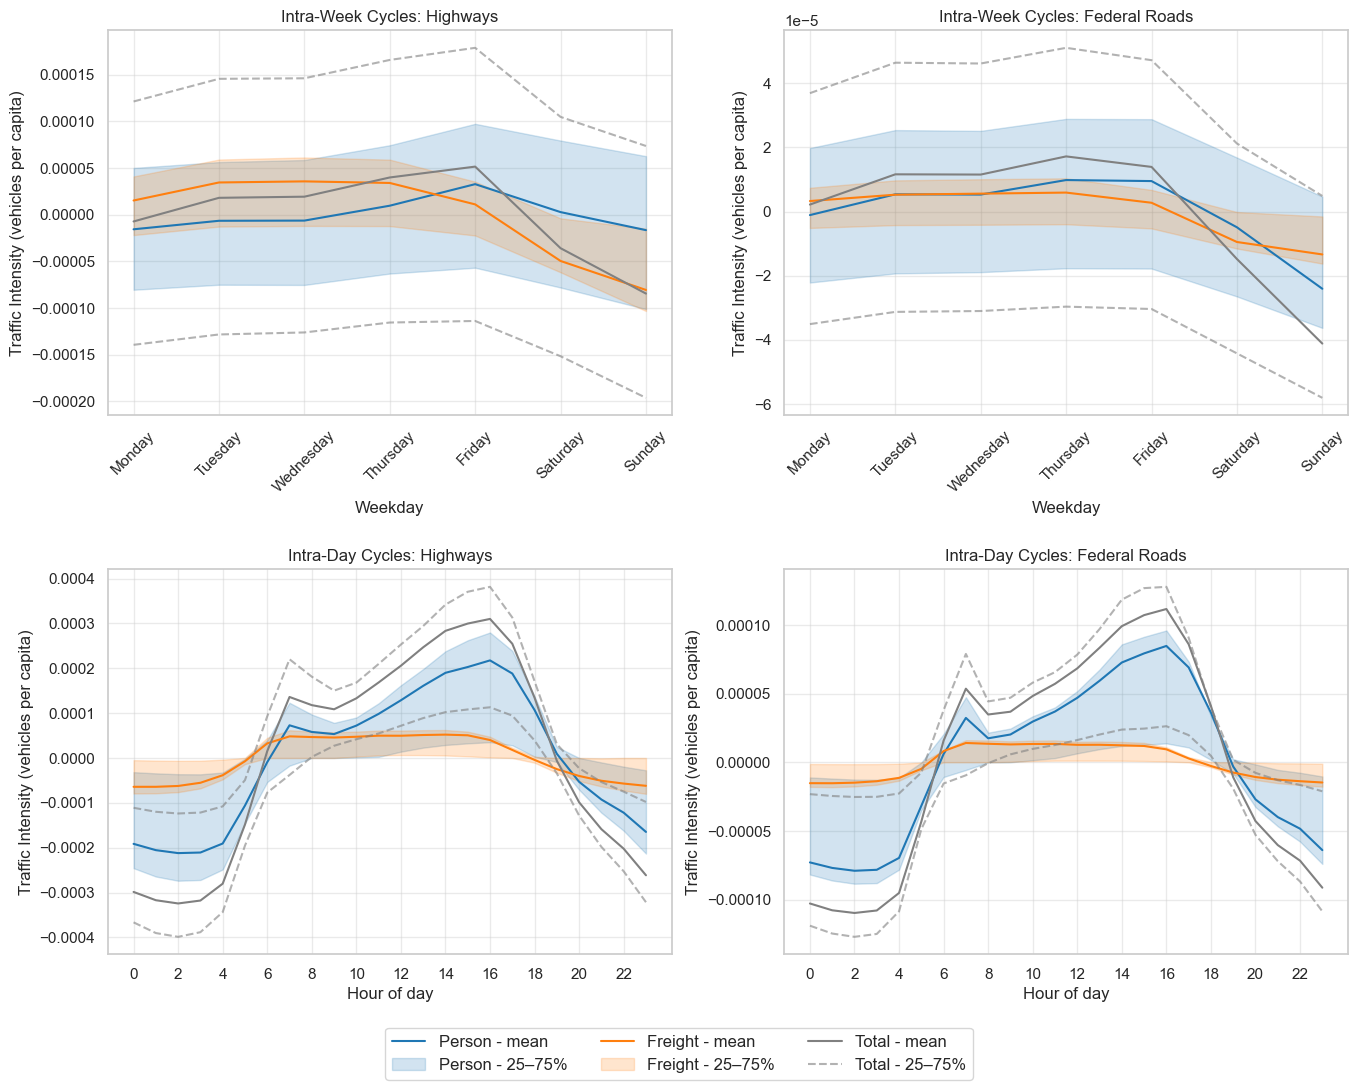

In [33]:
# Plotting Intra-week and Intra-day Traffic Intensity Cycles
def plot_band(ax, q_person, q_freight, total, title, x_is_weekday=True):
    # person
    ax.plot(q_person.index, q_person["mean"], label="Person - mean", color="tab:blue")
    ax.fill_between(q_person.index, q_person["q25"], q_person["q75"],
                    color="tab:blue", alpha=0.2, label="Person - 25–75%")
    # freight
    ax.plot(q_freight.index, q_freight["mean"], label="Freight - mean", color="tab:orange")
    ax.fill_between(q_freight.index, q_freight["q25"], q_freight["q75"],
                    color="tab:orange", alpha=0.2, label="Freight - 25–75%")
    # total
    ax.plot(total.index, total["mean"], label="Total - mean", color="gray", linestyle="-")
    ax.plot(total["q25"], color="gray", alpha=0.6, label="Total - 25–75%", linestyle="--")
    ax.plot(total["q75"], color="gray", alpha=0.6, linestyle="--")

    ax.set_title(title)
    ax.grid(True, alpha=0.4)

    if x_is_weekday:
        ax.set_xlabel("Weekday")
        ax.set_ylabel("Traffic Intensity (vehicles per capita)")
        ax.set_xticklabels(q_person.index, rotation=45)
    else:
        ax.set_xlabel("Hour of day")
        ax.set_ylabel("Traffic Intensity (vehicles per capita)")
        ax.set_xticks(range(0, 24, 2))


# Plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=False, gridspec_kw={'hspace': 0.4, 'wspace': 0.2} )

# Intra-Week Traffic Intensity Cycles
plot_band(axes[0, 0], 
          intraweek_int[("person_transport", "A")], 
          intraweek_int[("freight_transport", "A")], 
          intraweek_int[("total_vehicles", "A")],  
          "Intra-Week Cycles: Highways", x_is_weekday=True)
plot_band(axes[0, 1], 
          intraweek_int[("person_transport", "B")], 
          intraweek_int[("freight_transport", "B")], 
          intraweek_int[("total_vehicles", "B")],  
          "Intra-Week Cycles: Federal Roads", x_is_weekday=True)

# Intra-Day Traffic Intensity Cycles
plot_band(axes[1, 0], 
          intraday_int[("person_transport", "A")],
          intraday_int[("freight_transport", "A")], 
          intraday_int[("total_vehicles", "A")],
          "Intra-Day Cycles: Highways", x_is_weekday=False)
plot_band(axes[1, 1], 
          intraday_int[("person_transport", "B")], 
          intraday_int[("freight_transport", "B")], 
          intraday_int[("total_vehicles", "B")],
          "Intra-Day Cycles: Federal Roads", x_is_weekday=False)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, fontsize=12, frameon=True)
plt.savefig("Fig3.pdf", format="pdf")  
plt.show()


The above Plots show the intra-week cycles of traffic intensity for both highways and federal roads, separated by total, passenger and freight transportation. The solid lines represent the mean traffic intensity for each day of the week, while the shaded areas indicate the interquartile range (10th to 90th quantile), providing insight into the variability of traffic volumes. While the total traffic intensity exhibits clear weekly and daily patterns, the breakdown by transport type reveals distinct behaviors.

Clearly as expected, highway freight transportexhibits significantly drops due to legal driving restrictions on weekends. In contrast, passenger highway transport exhibits a pronounced peak around friday and drop on sundays/mondays. As cargo handing occurs increasingly on highways, federal roads show less pronounced intra-week cycles for freight transport but we still notice a small spill-over effect from weekend driving restrictions. Passenger transport on federal roads shows similar patterns as on highways, but with larger traffic volumes during the weak and lower volumes on weekends.

We now devote ourselves to traffic intensity cycles througout the day, that reveal substantial different patterns for passenger and freight transport. Passenger transport shows the typical bimodal distribution with morning and late afternoon peaks corresponding to commuting hours which is very similar for both highways and federal roads. In contrast, freight transport exhibits higher traffic volumes throughout the day compared to the night, reflecting the continuous nature of logistics operations. These distinct temporal patterns highlight the differing operational characteristics and demands of passenger versus freight transportation on Germany's road network.



## Data Analysis

After exploring the data, we now proceed to analyze the impact of the GDL strikes on road traffic volumes. Besides examining potential changes in overal traffic levels, the analysis focuses on quantifying changes in traffic patterns during the strike periods compared to baseline conditions. By doing so, we aim to uncover how disruptions in rail services influence road traffic dynamics across different vehicle types, road categories, and temporal dimensions, that may provide insights into modal shifts and adaptive behaviors among commuters and freight operators.       

The GDL Strike in January and March 2024 had the following characteristics:

In [34]:
table_data = """
Union | Strike_Number | Start_Time | End_Time | scope 
GDL | 1 | 09.01.2024 18:00 | 12.01.2024 18:00 | freight 
GDL | 1 | 10.01.2024 02:00 | 12.01.2024 18:00 | person 
GDL | 2 | 23.01.2024 18:00 | 27.01.2024 18:00 | freight 
GDL | 2 | 24.01.2024 02:00 | 29.01.2024 02:00 | person
GDL | 3 | 06.03.2024 18:00 | 08.03.2024 05:00 | freight 
GDL | 3 | 07.03.2024 02:00 | 08.03.2024 13:00 | person 
GDL | 4 | 11.03.2024 18:00 | 12.03.2024 18:00 | freight
GDL | 4 | 12.03.2024 02:00 | 13.03.2024 02:00 | person 
"""

# Read and tidy
df = pd.read_csv(io.StringIO(table_data), sep='|', skipinitialspace=True)
df = df.dropna(axis=1, how='all')
strike_time = df.copy()
strike_time

,Union,Strike_Number,Start_Time,End_Time,scope
0,GDL,1,09.01.2024 18:00,12.01.2024 18:00,freight
1,GDL,1,10.01.2024 02:00,12.01.2024 18:00,person
2,GDL,2,23.01.2024 18:00,27.01.2024 18:00,freight
3,GDL,2,24.01.2024 02:00,29.01.2024 02:00,person
4,GDL,3,06.03.2024 18:00,08.03.2024 05:00,freight
5,GDL,3,07.03.2024 02:00,08.03.2024 13:00,person
6,GDL,4,11.03.2024 18:00,12.03.2024 18:00,freight
7,GDL,4,12.03.2024 02:00,13.03.2024 02:00,person


In [35]:
df.columns = df.columns.str.strip()    
df["scope"] = df["scope"].str.strip()   
df["Start_Time"] = df["Start_Time"].str.strip()
df["End_Time"] = df["End_Time"].str.strip()    
df["Start_Time"] = pd.to_datetime(df["Start_Time"], format="%d.%m.%Y %H:%M")
df["End_Time"]   = pd.to_datetime(df["End_Time"],   format="%d.%m.%Y %H:%M")

time_index = pd.date_range(start="2024-01-01 00:00", end="2024-03-31 23:00", freq="H")
strike = pd.DataFrame(index=time_index, data={"strike": 0, "freight": 0, "person": 0})

# Strike Indicators
for _, row in df.iterrows():
    mask = (strike.index >= row["Start_Time"]) & (strike.index <= row["End_Time"])
    strike.loc[mask, "strike"] = 1
    typ = row["scope"].lower()
    if typ in ("freight", "person"):
        strike.loc[mask, typ] = 1

strike.head()

,strike,freight,person
2024-01-01 00:00:00,0,0,0
2024-01-01 01:00:00,0,0,0
2024-01-01 02:00:00,0,0,0
2024-01-01 03:00:00,0,0,0
2024-01-01 04:00:00,0,0,0


In [36]:
# Merging with traffic data (for later Times Series Decomposition)
df_strike = {}
for road in ['A', 'B']:
    df = df_complete[road]
    df = df.merge(strike, left_on='date_hour', right_index=True, how='left')
    df_strike[road] = df

In [37]:
print("Total Strike Hours in Sample:", strike['strike'].sum())
print("Total Passenger Strike Hours in Sample:", strike['person'].sum())
print("Total Freight Strike Hours in Sample:", strike['freight'].sum())

Total Strike Hours in Sample: 279
Total Passenger Strike Hours in Sample: 247
Total Freight Strike Hours in Sample: 231


For an initial assessment of the strike impact on road traffic volumes, we calculate for each station the mean traffic intensity during the strike periods and compare it to the mean traffic intensity during non-strike periods. The difference between these two means may provide a first measure of the strike's effect on road traffic volumes.

In [38]:
import geopandas as gpd

gdf = {}

for x in ['A', 'B']:
    df = df_strike[x]

    station_means = (
        df.groupby(['Zst', 'strike'])[f'intensity_total_vehicles_{x}']
          .mean()
          .unstack(fill_value=np.nan)   # columns: 0 → no strike, 1 → strike
          .rename(columns={0: 'total_intensity_mean_no_strike',
                           1: 'total_intensity_mean_strike'})
          .reset_index()
    )

    coords = (
        df.drop_duplicates('Zst')[['Zst', 'Koordinaten_UTM32_E', 'Koordinaten_UTM32_N']]
        .copy()
    )

    df_unique = coords.merge(station_means, on='Zst', how='left')

    gdf[x] = gpd.GeoDataFrame(
        df_unique,
        geometry=gpd.points_from_xy(df_unique["Koordinaten_UTM32_E"],
                                    df_unique["Koordinaten_UTM32_N"]),
        crs="EPSG:32632"
    ).to_crs(epsg=3857)

gdf_A = gdf['A']
gdf_B = gdf['B']


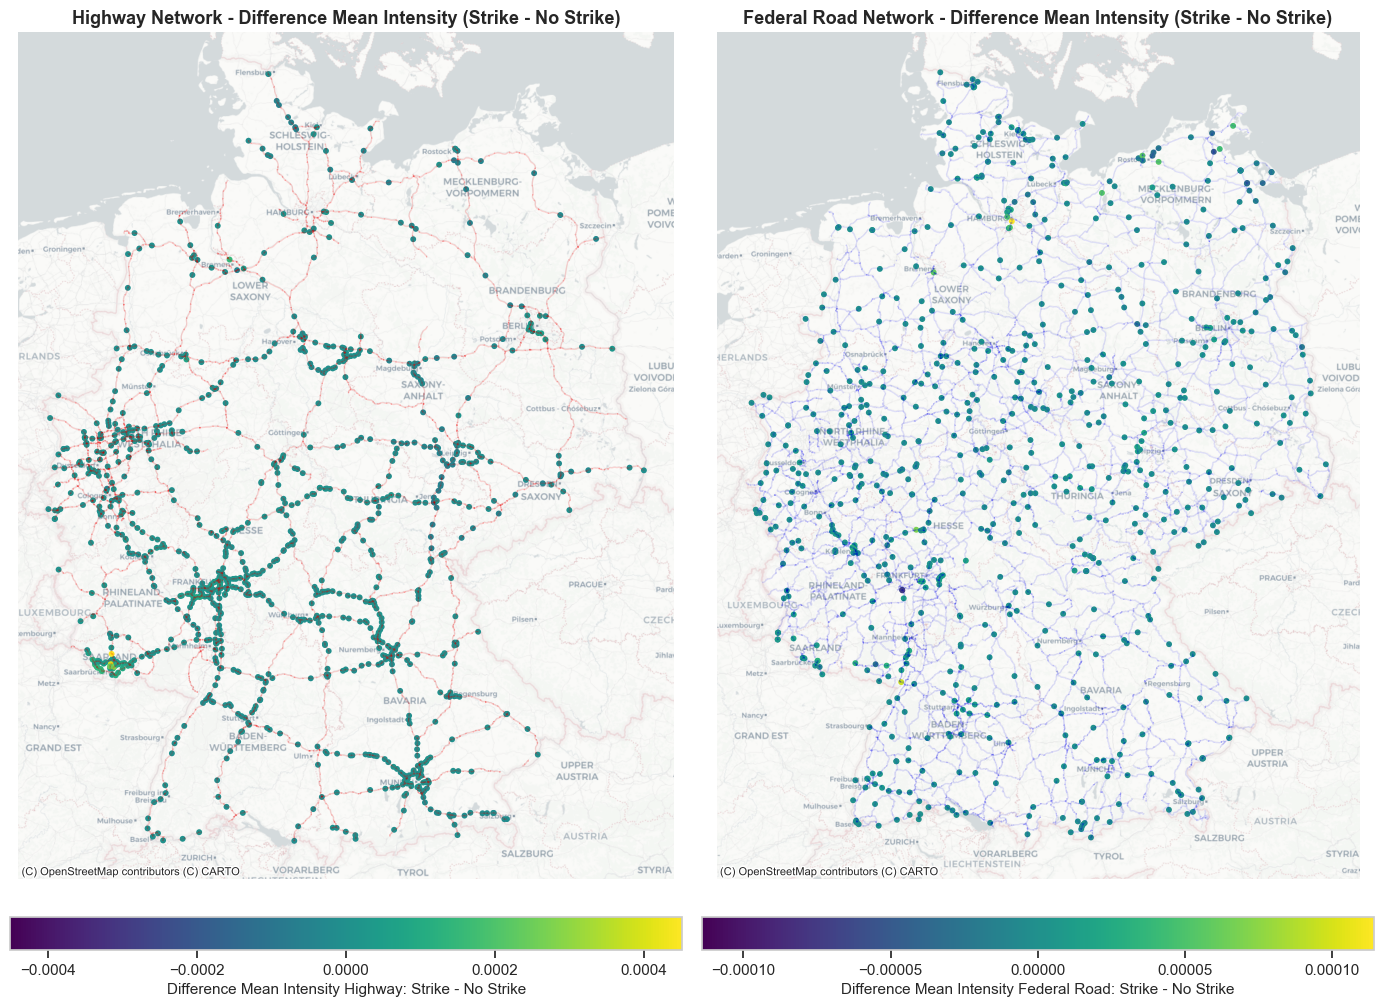

In [39]:

for gdf in [gdf_A, gdf_B]:
    if "diff_mean" not in gdf.columns:
        gdf["diff_mean"] = gdf["total_intensity_mean_strike"] - gdf["total_intensity_mean_no_strike"]

vals_A = gdf_A["diff_mean"].to_numpy()
vabs_A = np.nanmax(np.abs(vals_A)) if np.isfinite(vals_A).any() else 1.0
norm_A = TwoSlopeNorm(vmin=-vabs_A, vcenter=0.0, vmax=vabs_A)

vals_B = gdf_B["diff_mean"].to_numpy()
vabs_B = np.nanmax(np.abs(vals_B)) if np.isfinite(vals_B).any() else 1.0
norm_B = TwoSlopeNorm(vmin=-vabs_B, vcenter=0.0, vmax=vabs_B)

cmap = get_cmap("viridis")

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

ax1 = axes[0]
network_A.plot(ax=ax1, color="red", linewidth=1, alpha=0.05)
gdf_A.plot(
    ax=ax1,
    column="diff_mean",
    cmap=cmap,
    norm=norm_A,
    markersize=18,
    edgecolor="none",
    linewidth=0.3,
)
ctx.add_basemap(ax1, source=ctx.providers.CartoDB.Positron, zoom=7)
ax1.set_title("Highway Network - Difference Mean Intensity (Strike - No Strike)", fontsize=13, fontweight="bold")
ax1.set_axis_off()

ax2 = axes[1]
network_B.plot(ax=ax2, color="blue", linewidth=1, alpha=0.05)
gdf_B.plot(
    ax=ax2,
    column="diff_mean",
    cmap=cmap,
    norm=norm_B,
    markersize=18,
    edgecolor="none",
    linewidth=0.3,
)
ctx.add_basemap(ax2, source=ctx.providers.CartoDB.Positron, zoom=7)
ax2.set_title("Federal Road Network - Difference Mean Intensity (Strike - No Strike)", fontsize=13, fontweight="bold")
ax2.set_axis_off()

sm_A = ScalarMappable(norm=norm_A, cmap=cmap)
sm_A.set_array([])
cbar_A = fig.colorbar(sm_A, ax=ax1, orientation="horizontal", fraction=0.05, pad=0.04)
cbar_A.set_label("Difference Mean Intensity Highway: Strike - No Strike", fontsize=11)

sm_B = ScalarMappable(norm=norm_B, cmap=cmap)
sm_B.set_array([])
cbar_B = fig.colorbar(sm_B, ax=ax2, orientation="horizontal", fraction=0.05, pad=0.04)
cbar_B.set_label("Difference Mean Intensity Federal Road: Strike - No Strike", fontsize=11)

plt.tight_layout()
plt.show()


Indeed, by simply comparing mean differences in traffic intensity, a conclusion of higher traffic volumes during strikes cannot be concluded directly. While some stations exhibit increased traffic volumes during strike periods, others show decreases or negligible changes. This heterogeneity suggests that the strike's impact on road traffic is complex and may be influenced by various factors such as location, road type, and local commuting patterns. It is noteworthy, that this approach also does not take into account trends, which may be very differnt throughout the different strikes. Therefore, a more detailed analysis is required to understand the underlying dynamics and to identify specific conditions under which the strikes lead to significant changes in road traffic volumes.

We proceed with the analysis of the strike impact on road traffic volumes by taking into consideration the seasonality in traffic patterns identified in the previous section. Hence, we decompose the traffic volume time series into trend, seasonal, and residual components using seasonal decomposition techniques. This allows us to isolate the underlying trend and seasonal patterns from the observed data, enabling a clearer assessment of the strike's impact.

By doing so, we implement a tow-part STL decomposition (Seasonal and Trend decomposition using Loess) developed by Cleveland, Cleveland, McRae, & Terpenning (1990) that first removes the daily seasonality followed by the weakly seasonality of the time series. In order to identify the impact the GDL strike had on traffic volumes, we exclude the strike periods from the decomposition process to prevent strike-related anomalies from influencing the fitted seasonal or trend components. The residual component, which captures the irregular fluctuations in traffic volumes, is then analyzed to assess deviations from expected patterns during the strike periods.

The main decomposition is done in two parts: The first uses STL (Seasonal-Trend decomposition using Loess) with a 24-hour period to capture the daily cycles. After removing this daily component, the remaining variation is modeled with a Fourier regression using harmonics of a 168-hour (weekly) cycle to estimate smooth weekly seasonal effects. This is necessary since otherwise discontinous would result through the discrete nature of weekdays. Strike hours are excluded from this regression to ensure the weekly pattern reflects normal conditions. Once daily and weekly seasonality are removed, the code estimates the long-term trend using a robust rolling median and mean filter over a two-week window. This produces a smooth, outlier-resistant trend that captures gradual changes in overall activity. Finally, the residuals—the differences between the original series and the reconstructed trend plus seasonal components—highlight deviations such as strike effects or unusual events.

In [40]:
# Functions for time series decomoposition via two-part STL

ROADS = ['A', 'B']
COLS = {
    'person_transport_R1_R2': 'person',
    'freight_transport_R1_R2': 'freight',
}
INDICATOR_COLS: Iterable[str] = ('person', 'freight')

def prepare(df: pd.DataFrame,
            dt_col: str = 'date_hour',
            hourly_freq: str = 'H',
            indicator_cols: Iterable[str] = INDICATOR_COLS) -> pd.DataFrame:
    """
    Returns an hourly DataFrame with target cols + indicator columns
    (e.g., 'person', 'freight'), aggregated to date_hour, sorted,
    and time-interpolated to fill gaps.
    """
    needed = list(COLS.keys()) + list(indicator_cols)
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    out = (df
           .assign(**{dt_col: pd.to_datetime(df[dt_col])})
           .groupby(dt_col)[needed]
           .mean(numeric_only=True)
           .sort_index())

    out = (out
           .asfreq(hourly_freq)
           .interpolate(method='time', limit_direction='both'))

    return out

def _time_fill_for_stl(series: pd.Series,
                       strike_mask: pd.Series,
                       weekly_period: int,
                       fill_strategy: str = 'weekly_naive') -> pd.Series:
    """
    Produce a 'neutral' fill for masked hours so STL can run.
    - 'weekly_naive': y[t] = y[t-168h] where available, else time interpolate
    """
    y = series.astype(float).copy()
    if fill_strategy == 'weekly_naive':
        filled = y.copy()
        if weekly_period > 0 and weekly_period < len(y):
            shifted = y.shift(weekly_period)
            filled.loc[strike_mask] = shifted.loc[strike_mask]
        filled = filled.interpolate(method='time', limit_direction='both')
        return filled

def weekly_seasonality_hourly_fourier(y_filled_hourly: pd.Series,
                                      seasonal_daily_hourly: pd.Series,
                                      strike: Optional[pd.Series] = None,
                                      K: int = 4, # number of harmonics (lower K => smoother)
                                      add_intercept: bool = True) -> pd.Series:
    """
    Smooth hourly weekly seasonal via Fourier regression on the *hourly* remainder.
    - strike hours are excluded from the fit.
    Returns an hourly seasonal component (zero-mean).
    """
    rem = (y_filled_hourly - seasonal_daily_hourly).astype(float)
    mask = ~rem.isna()
    if strike is not None:
        strike = strike.reindex(rem.index).fillna(0).astype(bool)
        mask &= ~strike

    n = len(rem)
    t = np.arange(n, dtype=float)
    period = 168.0

    cols = []
    if add_intercept:
        cols.append(np.ones(n))
    for k in range(1, K + 1):
        cols.append(np.sin(2 * np.pi * k * t / period))
        cols.append(np.cos(2 * np.pi * k * t / period))
    X = np.column_stack(cols)

    beta, *_ = np.linalg.lstsq(X[mask], rem.values[mask], rcond=None)
    fitted = pd.Series(X @ beta, index=rem.index)
    fitted -= fitted.mean()
    return fitted

def smooth_trend_hourly(x: pd.Series,
                        window_hours: int = 24 * 14,
                        center: bool = True) -> pd.Series:
    """
    Simple robust trend: rolling median then rolling mean on the
    season-removed hourly series. Adjust window_hours (>= 24*7 recommended).
    """
    if x.index.freq is None:
        x = x.asfreq('H')

    w = max(3, int(window_hours))
    med = x.rolling(window=w, center=center, min_periods=max(1, w // 3)).median()
    trend = med.rolling(window=w, center=center, min_periods=max(1, w // 3)).mean()
    trend = trend.interpolate(method='time', limit_direction='both')
    return trend

def decompose_masked_multi(
        series: pd.Series,
        strike: pd.Series,
        daily_period: int = 24,
        weekly_period_hours: int = 24 * 7,  
        robust: bool = True,
        stl_kwargs_daily: Optional[Dict] = None,
        fill_strategy: Literal['weekly_naive', 'interpolate'] = 'weekly_naive',
        trend_window_hours: int = 24 * 14,
        weekly_fourier_K: int = 4,
) -> pd.DataFrame:
    """
    Two-pass with strike masking:
      1) Mask strike hours and neutral-fill.
      2) Daily STL (period=24) -> seasonal_daily.
      3) Smooth hourly weekly component via Fourier on the hourly remainder (period=168).
      4) Trend: robust rolling smoother on (y_filled - seasonal_daily - seasonal_weekly).
      5) Residuals vs ORIGINAL observed series.
    Returns DataFrame with columns:
      observed, trend, seasonal_daily, seasonal_weekly, resid
    """
    stl_kwargs_daily = dict(stl_kwargs_daily or {})
    strike = strike.reindex(series.index).fillna(0).astype(bool)
    y_filled = _time_fill_for_stl(
        series=series,
        strike_mask=strike,
        weekly_period=weekly_period_hours,
        fill_strategy=fill_strategy
    )
    res_daily = STL(y_filled, period=daily_period, robust=robust, **stl_kwargs_daily).fit()
    seasonal_daily = pd.Series(res_daily.seasonal, index=series.index)
    seasonal_weekly = weekly_seasonality_hourly_fourier(
        y_filled_hourly=y_filled,
        seasonal_daily_hourly=seasonal_daily,
        strike=strike,
        K=weekly_fourier_K,
        add_intercept=True
    )
    season_removed = y_filled - seasonal_daily - seasonal_weekly
    trend = smooth_trend_hourly(season_removed, window_hours=trend_window_hours)
    resid = series - trend - seasonal_daily - seasonal_weekly
    return pd.DataFrame({
        'observed':        series,
        'trend':           trend,
        'seasonal_daily':  seasonal_daily,
        'seasonal_weekly': seasonal_weekly,
        'resid':           resid,
    }, index=series.index)


In [41]:
results: Dict[str, Dict[str, pd.DataFrame]] = {}
for road in ROADS:
    df_road = prepare(df_strike[road]) 
    results[road] = {}
    for col, indicator_name in COLS.items():
        strike_mask = df_road[indicator_name]
        results[road][indicator_name] = decompose_masked_multi(
            series=df_road[col],
            strike=strike_mask,
            robust=True,
            fill_strategy='weekly_naive',  
            trend_window_hours=24 * 14,     
            weekly_fourier_K=4              
        )

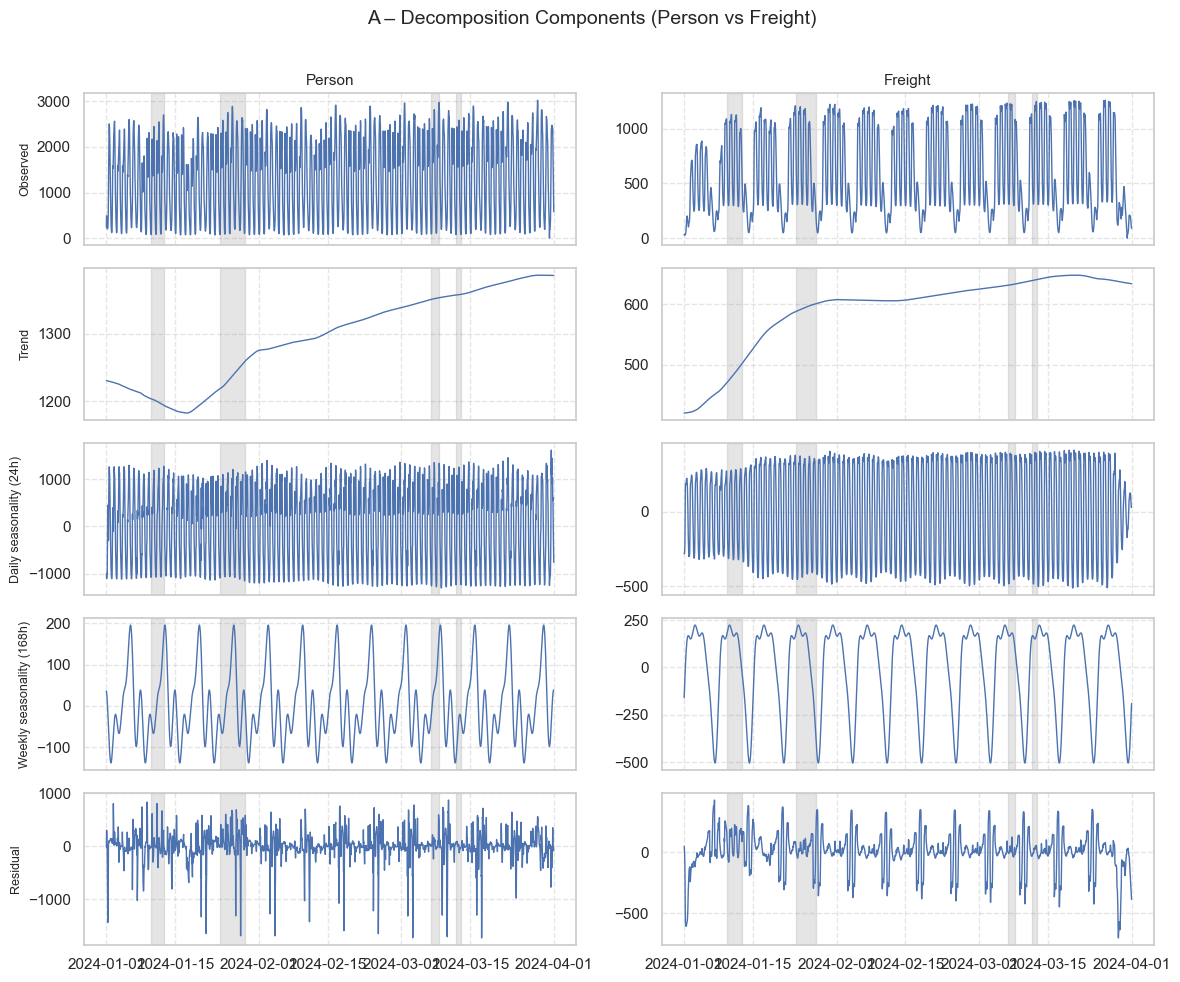

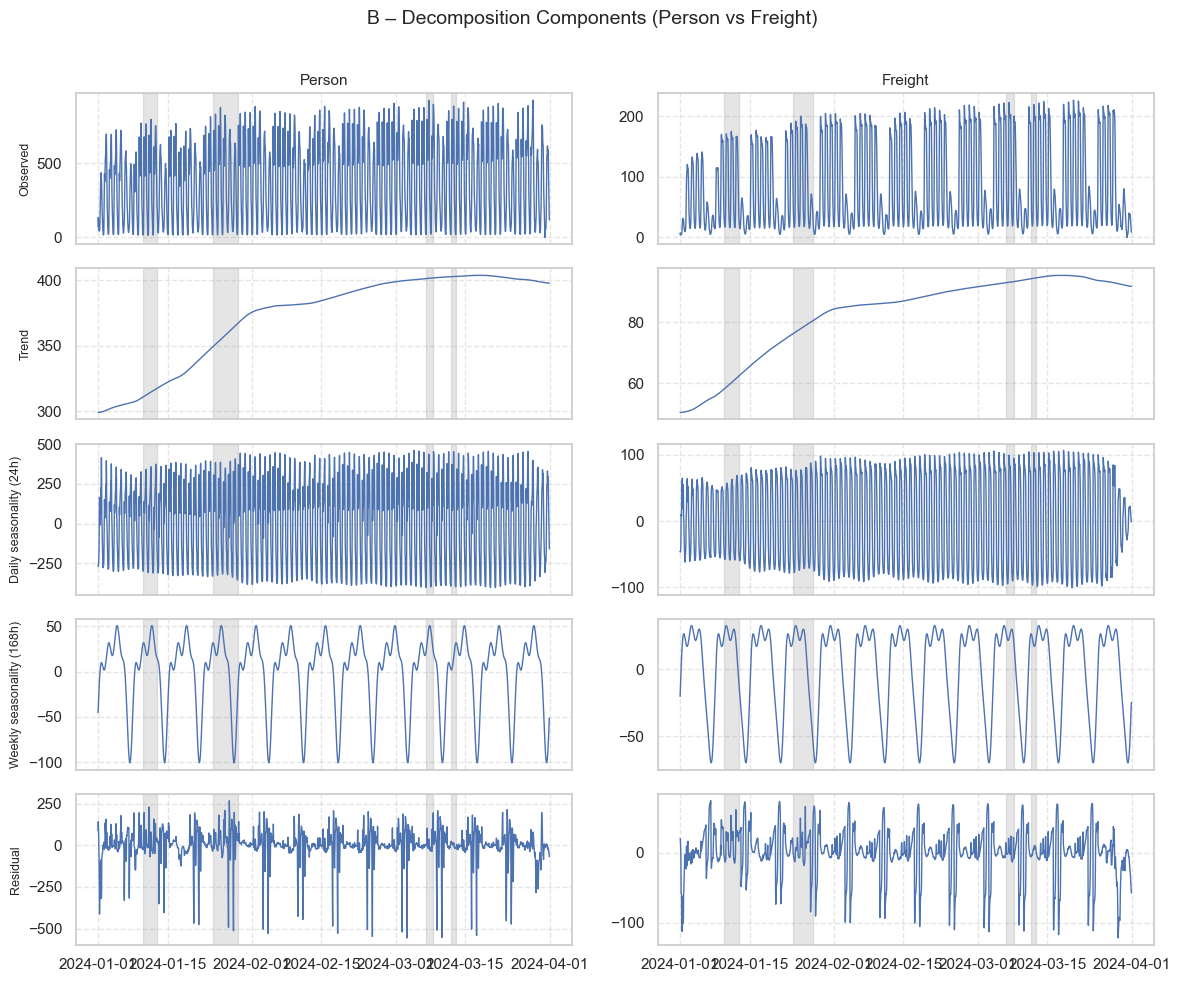

In [42]:
# Plot Times Series Decomposition Results
for road in ['A', 'B']:
    df_road = prepare(df_strike[road])

    fig, axes = plt.subplots(5, 2, figsize=(12, 10), sharex=True)
    fig.suptitle(f"{road} – Decomposition Components (Person vs Freight)", fontsize=14)

    for col, short_name in enumerate(['person', 'freight']):
        comp = results[road][short_name]
        components = [
            ('Observed', comp['observed']),
            ('Trend', comp['trend']),
            ('Daily seasonality (24h)', comp['seasonal_daily']),
            ('Weekly seasonality (168h)', comp['seasonal_weekly']),
            ('Residual', comp['resid'])
        ]

        for row, (title, series) in enumerate(components):
            ax = axes[row, col]
            ax.plot(series.index, series.values, linewidth=1)
            if col == 0:
                ax.set_ylabel(title, fontsize=9)
            if row == 0:
                ax.set_title(short_name.title(), fontsize=11)
            ax.grid(True, linestyle='--', alpha=0.5)

            indicator_series = df_road[short_name].reindex(comp.index).fillna(0).astype(int)
            in_block = False
            start = None
            for t, s in indicator_series.items():
                if s == 1 and not in_block:
                    in_block = True
                    start = t
                elif s == 0 and in_block:
                    end = t
                    ax.axvspan(start, end, color='gray', alpha=0.2)
                    in_block = False
            if in_block and start is not None:
                end = indicator_series.index[-1]
                ax.axvspan(start, end, color='gray', alpha=0.2)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig(f"Fig4_{road}.pdf", format="pdf")  
    plt.show()


As displayed, the STL decomposition effectively isolates the underlying trends and seasonal patterns. The top panel show the decompositions for both passenger and freight transportation for highways (A) and federal roads (B) separately. Clearly, we were able to isolate the daily and weekly seasonal cycles as identified in the explanatory analysis. Again, the respective plots depict the different patterns between vehicle types clearly. Moreover, the STL decomoposition reveals the identification of a long-term trend component that captures a gradual increase in traffic volumes over the whole observation period. What is left, is the residual component that contains irregular fluctioans that may not be explained by trend or seasonality, such as the effects of the GDL strikes. Thus, the later analysis will focus on the difference of explained variation and the residual component during the strike periods to quantify the strike impact on road traffic volumes.

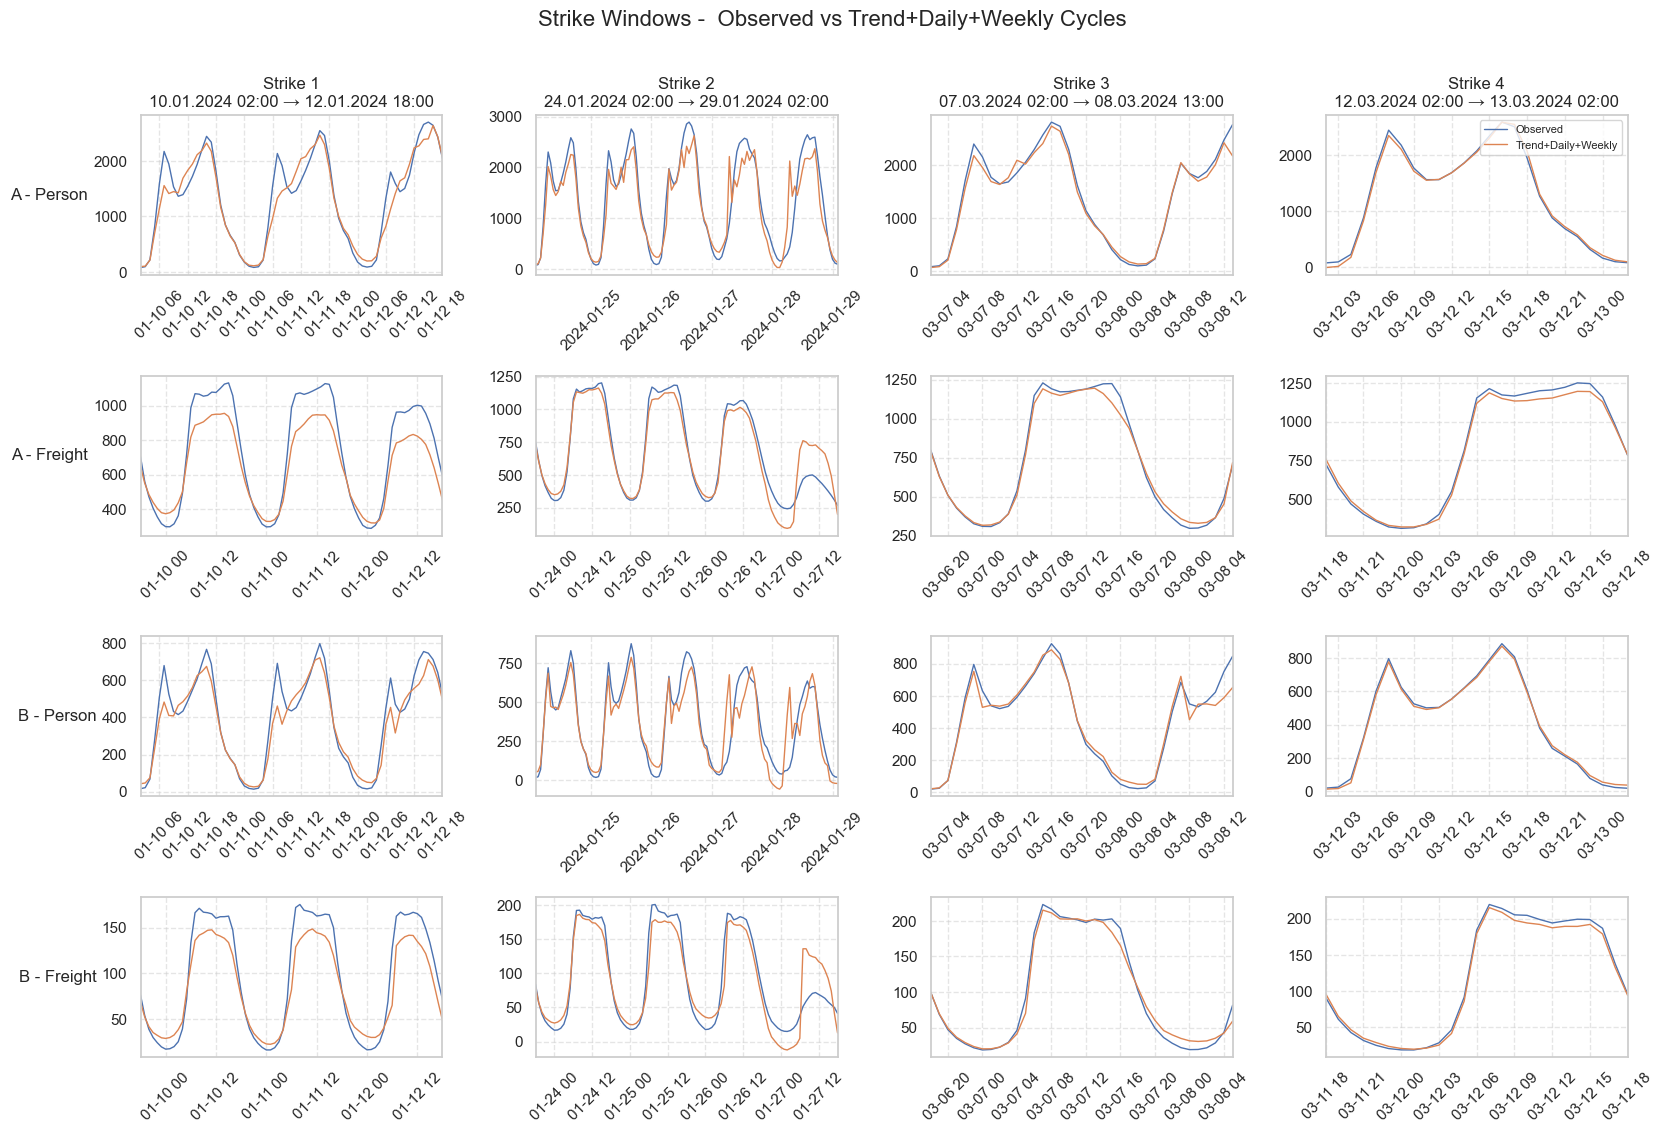

In [43]:
# Plot only Striking Windows with Observed vs Trend+Daily+Weekly
def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    def norm(c):
        c = str(c).strip()
        c = re.sub(r'[\s\-]+', '_', c)
        return c.strip('_').lower()
    return df.rename(columns={c: norm(c) for c in df.columns})

def build_strikes(strike_time: pd.DataFrame, union: str | None = None):
    df = _normalize_columns(strike_time).copy()

    required = {'strike_number', 'start_time', 'end_time', 'scope'}
    missing = required - set(df.columns)
    if missing:
        raise KeyError(f"Missing columns {missing}. Available: {list(df.columns)}")

    if union is not None and 'union' in df.columns:
        df = df[df['union'].astype(str) == str(union)]

    df['start_time'] = pd.to_datetime(df['start_time'], dayfirst=True, errors='coerce')
    df['end_time']   = pd.to_datetime(df['end_time'],   dayfirst=True, errors='coerce')
    if df['start_time'].isna().any() or df['end_time'].isna().any():
        bad = df[df['start_time'].isna() | df['end_time'].isna()]
        raise ValueError("Unparseable start/end times:\n" + bad.to_string(index=False))

    agg = (df.groupby(['strike_number','scope'], as_index=False)
             .agg(start_time=('start_time','min'),
                  end_time=('end_time','max')))

    strikes = []
    for sn, g in agg.sort_values('strike_number').groupby('strike_number'):
        entry = {}
        for _, row in g.iterrows():
            scope = str(row['scope']).strip().lower()
            if scope in ('person','freight'):
                entry[scope] = (row['start_time'], row['end_time'])
        if entry:
            strikes.append(entry)
    return strikes

STRIKES = build_strikes(strike_time, union=None)  

pairs = [(road, scope) for road in ['A','B'] for scope in ['person','freight']]
n_rows, n_cols = len(pairs), len(STRIKES)
s
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2*n_cols, 2.8*n_rows), sharex=False, sharey=False)
if n_rows == 1:
    axes = axes[None, :]

if n_cols == 1:
    axes = axes[:, None]


for r, (road, scope) in enumerate(pairs):
    df_road = prepare(df_strike[road])   
    comp = results[road][scope]              
    recon = comp['trend'] + comp['seasonal_daily'] + comp['seasonal_weekly']

    indicator_mask = df_road[scope].reindex(comp.index).fillna(0).astype(int).eq(1)

    for c, strike in enumerate(STRIKES):
        ax = axes[r, c]
        if scope not in strike:
            ax.set_axis_off()
            continue

        start, end = strike[scope]
        period_mask = (comp.index >= start) & (comp.index <= end)
        mask = indicator_mask & period_mask

        ax.plot(comp.index, comp['observed'].where(mask), linewidth=1)
        ax.plot(comp.index, recon.where(mask), linewidth=1)

        if r == 0:
            ax.set_title(f"Strike {c+1}\n{start:%d.%m.%Y %H:%M} → {end:%d.%m.%Y %H:%M}", fontsize=12)
        if c == 0:
            ax.set_ylabel(f"{road} - {scope.title()}", rotation=0, ha='right', va='center')

        ax.grid(True, linestyle='--', alpha=0.5)
        ax.tick_params(axis='x', rotation=45)
        ax.set_xlim(start, end)

        if r == 0 and c == n_cols - 1:
            ax.legend(['Observed', 'Trend+Daily+Weekly'], fontsize=8, loc='upper right')

plt.suptitle("Strike Windows -  Observed vs Trend+Daily+Weekly Cycles", fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig("Fig5.pdf", format="pdf")  
plt.show()



The figure shows observed road traffic volumes (blue lines) compared with reconstructed counterfactuals (brown lines; trend + daily + weekly cycles) for each train strike period, separated by road type and vehicle category. The top two rows correspond to highways (A), and the bottom two to federal roads (B).

Across all strikes, clear intra-day traffic cycles are visible, especially for passenger transport, reflecting typical commuting peaks in the morning and afternoon. These regular patterns are well captured by the counterfactual model but are consistently exceeded by the observed traffic during strike periods. This indicates that when train services are disrupted, additional passenger trips shift to the road network, particularly along highways where long-distance and regional commuting flows are concentrated. Freight traffic also shows some consistent increases relative to the counterfactual, which is most clearly in the first strike.

The later strikes (3 and 4) exhibit weaker deviations between observed and expected volumes, consistent with their shorter duration and a progressive adaptation of travelers and logistics operators. Overall, the plots highlight that train strikes amplify daily road traffic peaks, mainly affecting commuter-related passenger flows, with more pronounced effects on highways than on federal roads.

In [44]:
summary_rows = []

for road in ['A', 'B']:
    for scope in ['person', 'freight']:
        comp = results[road][scope].copy()
        comp['recon'] = comp['trend'] + comp['seasonal_daily'] + comp['seasonal_weekly']

        for i, strike in enumerate(STRIKES, start=1):
            if scope not in strike:
                continue

            start, end = strike[scope]
            period_mask = (comp.index >= start) & (comp.index < end)

            observed = comp.loc[period_mask, 'observed'].sum()
            recon_   = comp.loc[period_mask, 'recon'].sum()

            if recon_ == 0 or np.isnan(recon_):
                continue

            # Percentage difference based on total sums
            perc_diff = (observed - recon_) / recon_ * 100

            summary_rows.append({
                'road': road,
                'scope': scope,
                'strike_number': i,
                'observed_sum': observed,
                'recon_sum': recon_,
                'perc_diff': perc_diff
            })

df_sum_diff = pd.DataFrame(summary_rows).sort_values(['road', 'scope', 'strike_number']).reset_index(drop=True)

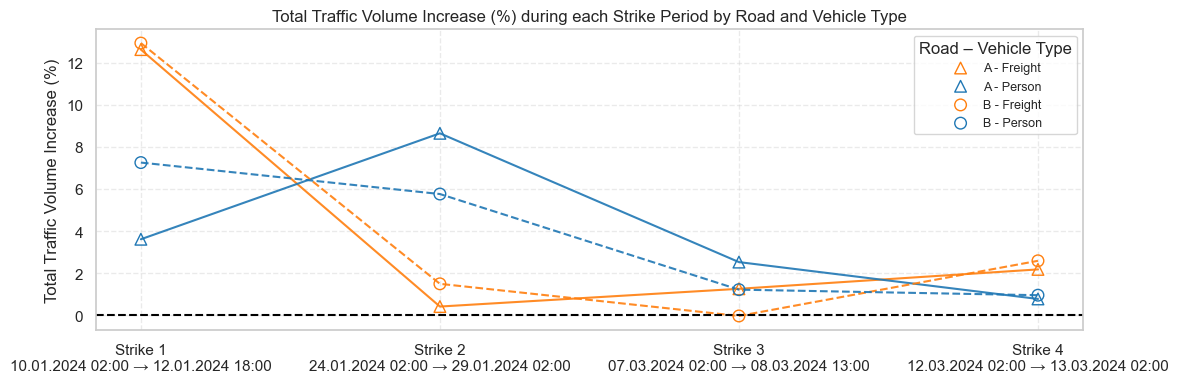

In [45]:
# Plot Analyis Results
fig, ax = plt.subplots(figsize=(12, 4))
strikes = sorted(df_sum_diff['strike_number'].unique())
scopes = ['person', 'freight']
roads = sorted(df_sum_diff['road'].unique())

group_centers = np.arange(len(strikes))
offsets = {'person': 0, 'freight': 0}

markers = {'A': '^', 'B': 'o'}
colors = {'person': 'tab:blue', 'freight': 'tab:orange'}
linestyles = {'A': '-', 'B': '--'} 

ax.axhline(0, ls='--', color='black' )

for (road, scope), g in df_sum_diff.groupby(['road', 'scope']):
    g = g.set_index('strike_number').reindex(strikes)
    if g['perc_diff'].isna().all():
        continue

    x = group_centers + offsets[scope]
    y = g['perc_diff']

    ax.scatter(
        x, y,
        marker=markers[road],
        s=70,
        facecolors='none',
        edgecolor=colors[scope],
        lw=1,
        label=f"{road} - {scope.title()}",
        zorder=2
    )

    ax.plot(
        x, y,
        color=colors[scope],
        linestyle=linestyles[road],
        lw=1.5,
        alpha=0.9,
        zorder=1
    )

strike_labels = [
    "Strike 1\n10.01.2024 02:00 → 12.01.2024 18:00",
    "Strike 2\n24.01.2024 02:00 → 29.01.2024 02:00",
    "Strike 3\n07.03.2024 02:00 → 08.03.2024 13:00",
    "Strike 4\n12.03.2024 02:00 → 13.03.2024 02:00",
]

ax.set(
    xticks=group_centers,
    xticklabels=strike_labels,
    ylabel="Total Traffic Volume Increase (%)",
    title="Total Traffic Volume Increase (%) during each Strike Period by Road and Vehicle Type"
)

ax.grid(True, ls='--', alpha=0.4)
ax.legend(title="Road – Vehicle Type", fontsize=9)
plt.tight_layout()
plt.savefig("Fig6.pdf", format="pdf")  
plt.show()


The figure shows how road traffic volume changed during each train strike period, separated by road and vehicle type. The largest increases in road traffic occurred during the first strike, particularly for freight vehicles on federal roads, suggesting that the initial train disruption caused substantial diversion from rail to road. In subsequent strikes, the percentage increases declined steadily across all categories, with both person and freight traffic returning close to expected (non-strike) levels by the last strike in march. This pattern in combination with the overall trend increase in traffic volume from the prior graph indicates that over time, travelers and freight operators adapted to the strike conditions, reducing the overall impact on road traffic volumes. Additionally, the last two train strikes were considerably shorter than the first two, which likely also contributed to their more limited effects on road traffic.

In [46]:
df_sum_diff.sort_values(['strike_number','scope','road'])
df_sum_diff

,road,scope,strike_number,observed_sum,recon_sum,perc_diff
0,A,freight,1,52378.865783,46506.589062,12.626763
1,A,freight,2,65000.293289,64734.694575,0.410288
2,A,freight,3,24557.945484,24253.872015,1.253711
3,A,freight,4,19709.203417,19289.442477,2.176118
4,A,person,1,85033.662800,82071.402695,3.609369
5,A,person,2,164902.706711,151779.660007,8.646117
6,A,person,3,49312.443450,48098.617182,2.523620
7,A,person,4,31482.136697,31241.131017,0.771437
8,B,freight,1,6845.632768,6061.421929,12.937737
9,B,freight,2,8708.090395,8580.203342,1.490490


During the GDL train strikes between January and March, road traffic increased modestly across both highways and federal roads. On the highway, freight traffic rose the most during the first strike, by about 12.6%, and then stabilized at smaller increases of around 0.4–2% in later strikes. Personal vehicle traffic on the highway also increased, ranging from roughly 0.8% to 8.6%, with the largest rise during the second strike. On the federal roads, freight traffic showed a strong initial rise of about 12.9% during the first strike but stayed below 3% afterward. Personal vehicle traffic increased more steadily, between about 1% and 7%, with the first and second strikes having the most noticeable effects.
Overall, the first GDL strike in January caused the largest traffic increases, especially for freight, while later strikes saw smaller but consistent rises across both vehicle categories. Indeed, longer striking periods led to more pronounced shifts from rail to road, but as the strikes shortened and travelers adapted, the impact on road traffic diminished.

## Conclusion

This project provides a data-driven, insightful assessment of the impact of the GDL train strikes (January–March 2024) on Germany’s road traffic patterns. It reveals the behavioural responses of travellers and the systemic impact on freight logistics. After berforing a thorough data exploration, we identfiy substantial regional differences in traffic volumns for passenger and freight transportation across space and time. This motivated the two-part seasonal-trend decomposition approach to isolate strike effects from regular traffic patterns.

The analysis captured short-term modal shifts from rail to road, quantifying these effects across highways and federal roads, as well as between freight and personal vehicle categories. The findings indicate a consistent and measurable increase in traffic volumes during the strike periods, particularly during the first GDL strike in January, when freight traffic increased by around 12–13% and passenger traffic by 4–9%. The effects were most pronounced on motorways, highlighting their pivotal role in accommodating diverted rail freight. Federal roads, though less affected, also exhibited steady increases, likely reflecting regional commuting adjustments and last-mile freight redistribution.

From a critical perspective, several patterns suggest adaptive behaviour and diminishing marginal effects across successive strikes. While the initial disruption caused strong, immediate shifts, subsequent shorter strikes in February and March produced smaller, yet still significant, increases. This implies that logistics networks and commuters had partially adapted their routines by rescheduling, working remotely, or planning transport in advance. Nevertheless, these adaptations did not eliminate the strain on road infrastructure, with elevated heavy-vehicle flows continuing even after the initial event.

## Impact

The above analysis provides valuable insights into the implications of railway distrubtions and its effect on mode subsitution patterns. This is relevant for several reasons. First, understanding how commuters and freight operators respond may give insights into the resilience of transportation networks, and help identify vulnerabilities that could be mitigated through better planning or infrastructure investments. Second, quantifying the magnitude and duration of modal shifts can inform future strike management strategies, such as targeted communication campaigns or temporary traffic regulations to alleviate congestion. Third, the findings highlight the critical role of highways in absorbing diverted freight traffic, underscoring the need for robust road infrastructure to support logistics continuity during rail disruptions.


## Next Steps

This study has to be viewed as being a preliminary assessment of mode substitution patterns during railway strikes. Several avenues for future research and analysis could further enhance understanding in this context. First, the time series decomposition relied on an aggregate measure of each station's traffic volume. Future work could allow for a more flexible estimation by allowing for station-specific seasonal and trend components, which may capture local variations in traffic patterns more accurately. Second, incorporating additional covariates such as weather conditions, special events, or concurrent roadworks could help isolate the strike effect from other influencing factors. Third, the increased freight traffic observed during striking periods motivates a wider analysis on the broad economy and welfare.